# Machine Learning & Predictive Modeling
## Insurance Risk Analytics - Task 4

This notebook builds and evaluates predictive models for dynamic, risk-based pricing.

## Objectives

1. **Claim Severity Prediction**: Build models to predict TotalClaims (using charges as proxy)
2. **Premium Optimization**: Develop ML models to predict optimal premium values
3. **Regional Models**: Build linear regression models per region (adapting from zipcode requirement)
4. **Model Evaluation**: Compare multiple algorithms (Linear Regression, Decision Trees, Random Forest, XGBoost)
5. **Feature Importance**: Analyze which features drive predictions using SHAP values
6. **Business Insights**: Provide actionable recommendations for risk-based pricing

## Data Adaptations

**Note**: The current dataset structure:
- **Available**: age, sex, bmi, children, smoker, region, charges
- **Missing**: TotalClaims, TotalPremium, CalculatedPremiumPerTerm, zip codes

**Adaptations**:
- Use **charges** as proxy for TotalClaims (claim severity)
- Use **charges** as proxy for premium (risk-based pricing)
- Create synthetic **claim indicator** (binary: has_claim) based on charges threshold
- Build regional models instead of zipcode models (4 regions available)


## 1. Setup and Data Loading


In [39]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import sys
import os

# Machine Learning imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# SHAP for interpretability
import shap

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [ ]:
# Add src to path - robust path resolution
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

src_path = project_root / 'src'
if src_path.exists():
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
    print(f"✓ Added to path: {src_path}")
else:
    print(f"⚠ Warning: Could not find src directory")

# Import custom modules
try:
    from data_loader import load_insurance_data
    from ml_utils import (
        prepare_features,
        train_linear_regression,
        train_decision_tree,
        train_random_forest,
        train_xgboost,
        get_feature_importance,
        calculate_shap_values,
        compare_models,
        create_claim_indicator
    )
    print("✓ Custom modules imported successfully!")
except ImportError as e:
    print(f" Import error: {e}")
    raise

# Create figures directory
figures_dir = project_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"✓ Figures directory: {figures_dir}")


✓ Added to path: d:\kifyaAi\insurance-risk-analytics\src
✓ Custom modules imported successfully!
✓ Figures directory: d:\kifyaAi\insurance-risk-analytics\reports\figures


✓ Data loaded: 1338 rows, 7 columns

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

First few rows:
✓ Saved figure: d:\kifyaAi\insurance-risk-analytics\reports\figures\ml_data_overview.png


<Figure size 1000x600 with 0 Axes>

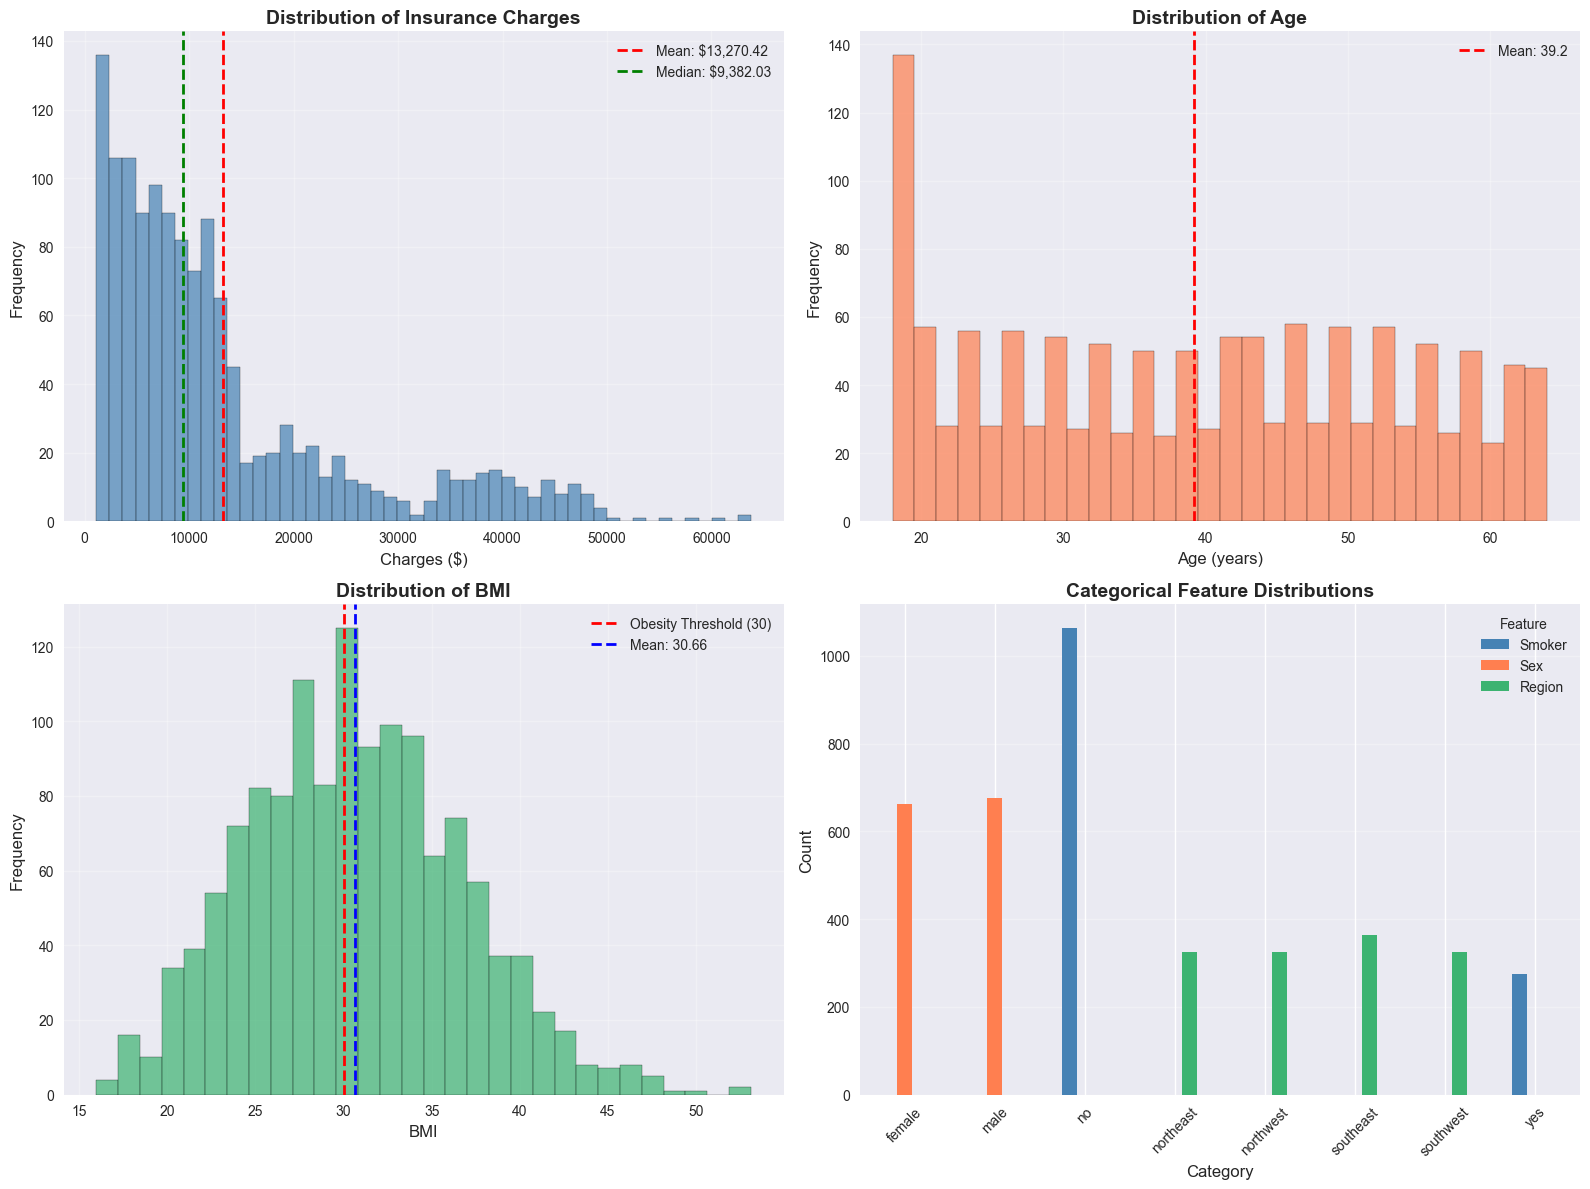

In [41]:
# Load data
df = load_insurance_data()
print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Info:")
print(df.info())
print(f"\nFirst few rows:")
df.head()

# ============================================================================
# DATA OVERVIEW VISUALIZATIONS
# ============================================================================
# Visualize key features to understand the data distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Charges distribution
axes[0, 0].hist(df['charges'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["charges"].mean():,.2f}')
axes[0, 0].axvline(df['charges'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["charges"].median():,.2f}')
axes[0, 0].set_xlabel('Charges ($)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Age distribution
axes[0, 1].hist(df['age'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
axes[0, 1].set_xlabel('Age (years)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Age', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. BMI distribution
axes[1, 0].hist(df['bmi'], bins=30, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1, 0].axvline(30, color='red', linestyle='--', linewidth=2, label='Obesity Threshold (30)')
axes[1, 0].axvline(df['bmi'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df["bmi"].mean():.2f}')
axes[1, 0].set_xlabel('BMI', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of BMI', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Categorical features
cat_counts = pd.DataFrame({
    'Smoker': df['smoker'].value_counts(),
    'Sex': df['sex'].value_counts(),
    'Region': df['region'].value_counts()
})
cat_counts.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'coral', 'mediumseagreen'])
axes[1, 1].set_xlabel('Category', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].set_title('Categorical Feature Distributions', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Feature')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
fig_path = figures_dir / 'ml_data_overview.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


## 2. Data Preparation and Feature Engineering


✓ Claim indicator created

Claim Distribution:
has_claim
1    669
0    669
Name: count, dtype: int64

Claim Rate: 50.00%

✓ Feature engineering completed

New columns: ['has_claim', 'age_squared', 'bmi_category', 'age_group']
✓ Saved figure: d:\kifyaAi\insurance-risk-analytics\reports\figures\ml_feature_engineering.png


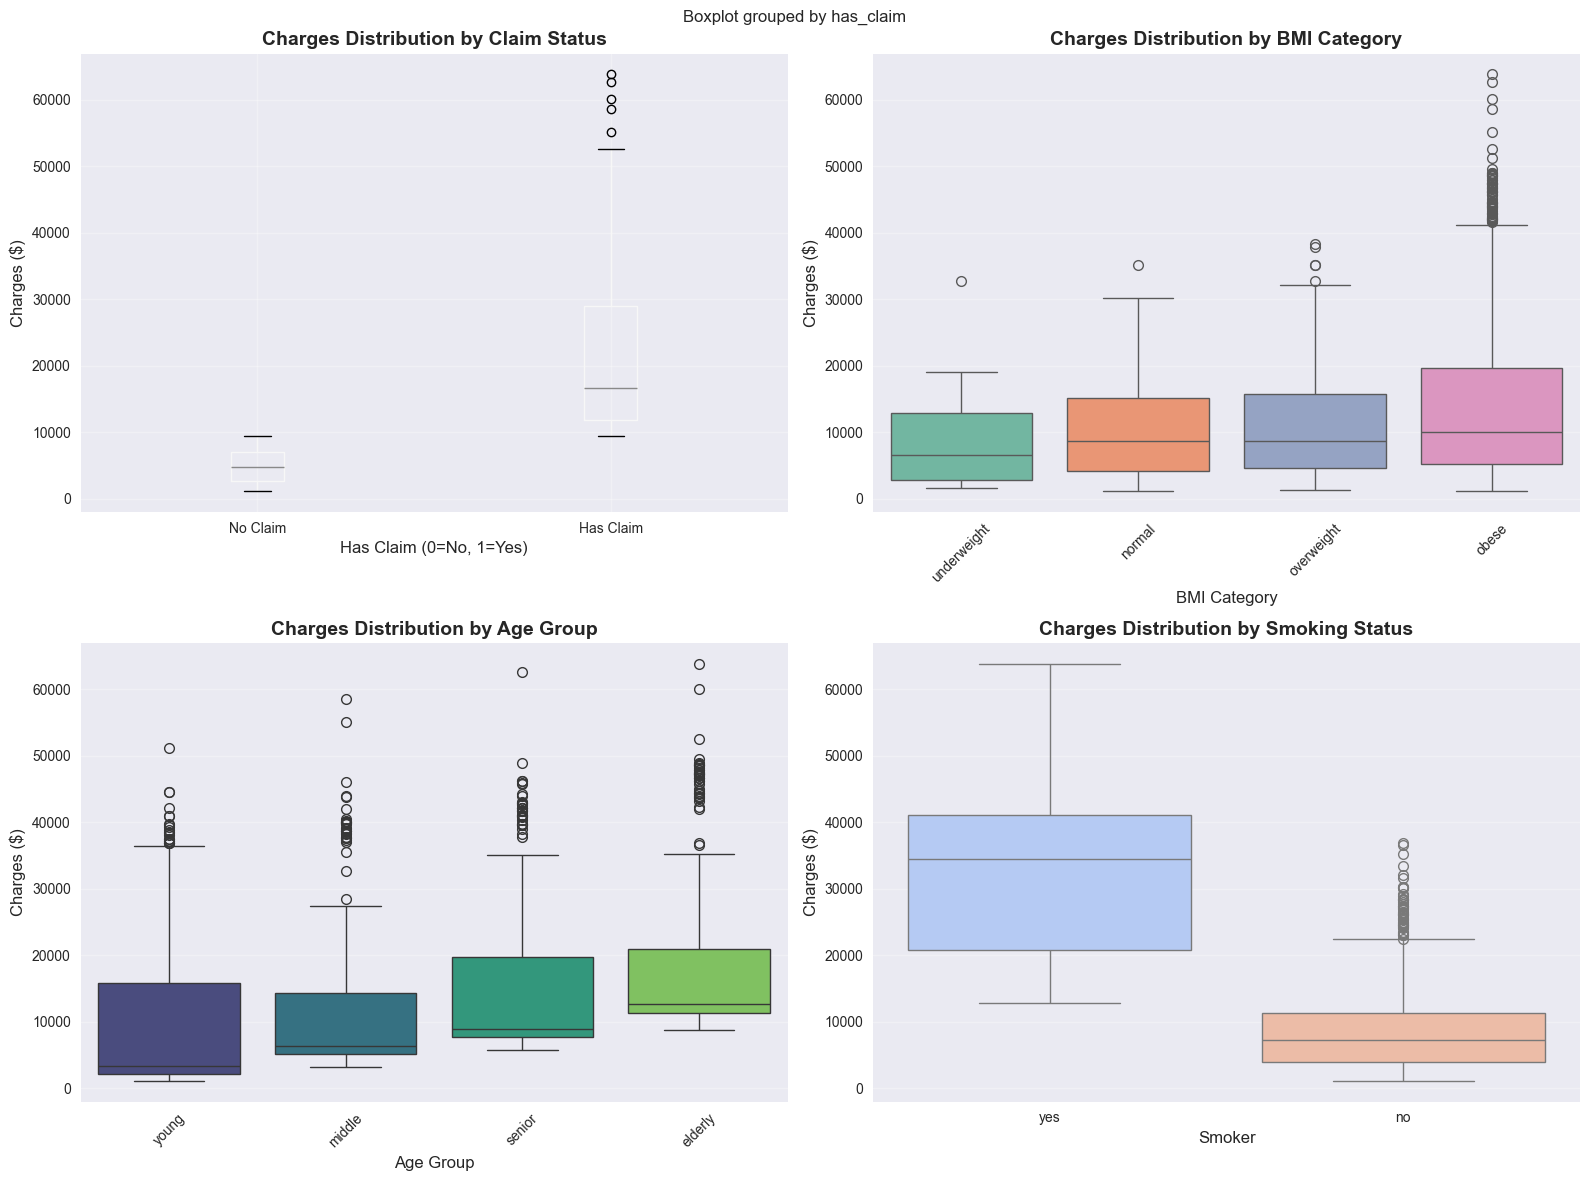

In [42]:
# Create claim indicator (binary: has_claim)
# Since we don't have explicit claim data, we'll create a synthetic indicator
# where claims > 0 if charges exceed median (simulating claim occurrence)
df = create_claim_indicator(df, charges_col='charges')

print("✓ Claim indicator created")
print(f"\nClaim Distribution:")
print(df['has_claim'].value_counts())
print(f"\nClaim Rate: {df['has_claim'].mean():.2%}")

# Feature engineering
# Create additional features that might be relevant
df['age_squared'] = df['age'] ** 2
df['bmi_category'] = pd.cut(df['bmi'], 
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['underweight', 'normal', 'overweight', 'obese'])
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 30, 40, 50, 100],
                         labels=['young', 'middle', 'senior', 'elderly'])

print("\n✓ Feature engineering completed")
print(f"\nNew columns: {[col for col in df.columns if col not in ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']]}")

# ============================================================================
# FEATURE ENGINEERING VISUALIZATIONS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Charges by claim status
df.boxplot(column='charges', by='has_claim', ax=axes[0, 0])
axes[0, 0].set_title('Charges Distribution by Claim Status', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Has Claim (0=No, 1=Yes)', fontsize=12)
axes[0, 0].set_ylabel('Charges ($)', fontsize=12)
axes[0, 0].set_xticklabels(['No Claim', 'Has Claim'])
axes[0, 0].grid(True, alpha=0.3)

# 2. Charges by BMI category
bmi_order = ['underweight', 'normal', 'overweight', 'obese']
df_plot = df[df['bmi_category'].isin(bmi_order)]
sns.boxplot(data=df_plot, x='bmi_category', y='charges', order=bmi_order, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Charges Distribution by BMI Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('BMI Category', fontsize=12)
axes[0, 1].set_ylabel('Charges ($)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Charges by age group
age_order = ['young', 'middle', 'senior', 'elderly']
df_plot2 = df[df['age_group'].isin(age_order)]
sns.boxplot(data=df_plot2, x='age_group', y='charges', order=age_order, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Charges Distribution by Age Group', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Age Group', fontsize=12)
axes[1, 0].set_ylabel('Charges ($)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Charges by smoker status
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Charges Distribution by Smoking Status', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Smoker', fontsize=12)
axes[1, 1].set_ylabel('Charges ($)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig_path = figures_dir / 'ml_feature_engineering.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


In [43]:
# Define features for modeling
categorical_cols = ['sex', 'smoker', 'region', 'bmi_category', 'age_group']
numerical_cols = ['age', 'bmi', 'children', 'age_squared']

# ============================================================================
# DATA PREPARATION: Handling Missing Data
# ============================================================================
# Check for missing values - impute or remove based on nature and quantity
print("="*70)
print("STEP 1: HANDLING MISSING DATA")
print("="*70)
missing_counts = df[categorical_cols + numerical_cols + ['charges', 'has_claim']].isnull().sum()
print("Missing values check:")
print(missing_counts)

# Strategy: Since we have no missing values, no imputation needed
# If missing values existed, we would:
# - For numerical: impute with median (robust to outliers) or mean
# - For categorical: impute with mode or create 'missing' category
# - Remove rows if >50% of features are missing
if missing_counts.sum() == 0:
    print("✓ No missing values detected - data is complete")
else:
    print(f"⚠ Found {missing_counts.sum()} missing values - applying imputation strategy")
    # Example imputation (if needed):
    # from sklearn.impute import SimpleImputer
    # imputer = SimpleImputer(strategy='median')  # or 'mean', 'most_frequent'
    # df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# ============================================================================
# DATA PREPARATION: Feature Engineering (already done above)
# ============================================================================
print("\n" + "="*70)
print("STEP 2: FEATURE ENGINEERING")
print("="*70)
print("✓ Created features:")
print("  - age_squared: Age squared (captures non-linear age effects)")
print("  - bmi_category: BMI categories (underweight, normal, overweight, obese)")
print("  - age_group: Age groups (young, middle, senior, elderly)")
print("  - has_claim: Binary claim indicator (for classification task)")

# ============================================================================
# DATA PREPARATION: Encoding Categorical Data
# ============================================================================
print("\n" + "="*70)
print("STEP 3: ENCODING CATEGORICAL DATA")
print("="*70)
print(f"Categorical columns to encode: {categorical_cols}")
print("Encoding method: One-hot encoding (creates binary columns for each category)")
print("  - Advantage: No ordinal assumption, works well with tree-based models")
print("  - Alternative: Label encoding (if ordinal relationship exists)")

# ============================================================================
# DATA PREPARATION: Train-Test Split
# ============================================================================
print("\n" + "="*70)
print("STEP 4: TRAIN-TEST SPLIT")
print("="*70)
print("Split ratio: 80:20 (80% training, 20% testing)")
print("Random state: 42 (for reproducibility)")
print("  - Training set: Used to build models")
print("  - Test set: Used to evaluate model performance (unseen data)")

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY FOR MODELING")
print("="*70)
print(f"Total records: {len(df)}")
print(f"Features: {len(categorical_cols + numerical_cols)}")
print(f"  - Categorical: {len(categorical_cols)}")
print(f"  - Numerical: {len(numerical_cols)}")
print(f"Target variables:")
print(f"  - charges (for regression: claim severity & premium prediction)")
print(f"  - has_claim (for classification: claim probability)")
print("="*70)


STEP 1: HANDLING MISSING DATA
Missing values check:
sex             0
smoker          0
region          0
bmi_category    0
age_group       0
age             0
bmi             0
children        0
age_squared     0
charges         0
has_claim       0
dtype: int64
✓ No missing values detected - data is complete

STEP 2: FEATURE ENGINEERING
✓ Created features:
  - age_squared: Age squared (captures non-linear age effects)
  - bmi_category: BMI categories (underweight, normal, overweight, obese)
  - age_group: Age groups (young, middle, senior, elderly)
  - has_claim: Binary claim indicator (for classification task)

STEP 3: ENCODING CATEGORICAL DATA
Categorical columns to encode: ['sex', 'smoker', 'region', 'bmi_category', 'age_group']
Encoding method: One-hot encoding (creates binary columns for each category)
  - Advantage: No ordinal assumption, works well with tree-based models
  - Alternative: Label encoding (if ordinal relationship exists)

STEP 4: TRAIN-TEST SPLIT
Split ratio: 80:2

## 3. Claim Severity Prediction (Risk Model)

**Objective**: Predict TotalClaims (using charges as proxy) for policies that have claims.

**Target Variable**: `charges` (for subset where `has_claim == 1`)  
**Evaluation Metrics**: RMSE, R², MAE


In [44]:
# Prepare data for claim severity prediction
# Use only records with claims (has_claim == 1)
df_claims = df[df['has_claim'] == 1].copy()

print(f"Records with claims: {len(df_claims)} ({len(df_claims)/len(df):.1%} of total)")
print(f"\nCharges statistics for claims subset:")
print(df_claims['charges'].describe())

# Prepare features
X_train_claims, X_test_claims, y_train_claims, y_test_claims, feature_names_claims, encoders_claims = prepare_features(
    df_claims,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    target_col='charges',
    test_size=0.2,
    random_state=42,
    encode_method='onehot'
)

print(f"\n✓ Data prepared for claim severity prediction")
print(f"Training set: {len(X_train_claims)} samples")
print(f"Test set: {len(X_test_claims)} samples")
print(f"Features: {len(feature_names_claims)}")


Records with claims: 669 (50.0% of total)

Charges statistics for claims subset:
count      669.000000
mean     21621.461896
std      12169.248391
min       9386.161300
25%      11879.104050
50%      16657.717450
75%      28923.136920
max      63770.428010
Name: charges, dtype: float64

✓ Data prepared for claim severity prediction
Training set: 535 samples
Test set: 134 samples
Features: 15


### 3.1 Train Multiple Models for Claim Severity


In [45]:
# Store models and results
claim_models = {}
claim_results = {}

# 1. Linear Regression
print("Training Linear Regression...")
model_lr, metrics_lr = train_linear_regression(
    X_train_claims, y_train_claims, X_test_claims, y_test_claims
)
claim_models['Linear Regression'] = model_lr
claim_results['Linear Regression'] = metrics_lr
print(f"  Test RMSE: ${metrics_lr['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_lr['test_r2']:.4f}")

# 2. Decision Tree
print("\nTraining Decision Tree...")
model_dt, metrics_dt = train_decision_tree(
    X_train_claims, y_train_claims, X_test_claims, y_test_claims,
    max_depth=10, min_samples_split=5
)
claim_models['Decision Tree'] = model_dt
claim_results['Decision Tree'] = metrics_dt
print(f"  Test RMSE: ${metrics_dt['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_dt['test_r2']:.4f}")

# 3. Random Forest
print("\nTraining Random Forest...")
model_rf, metrics_rf = train_random_forest(
    X_train_claims, y_train_claims, X_test_claims, y_test_claims,
    n_estimators=100, max_depth=10
)
claim_models['Random Forest'] = model_rf
claim_results['Random Forest'] = metrics_rf
print(f"  Test RMSE: ${metrics_rf['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_rf['test_r2']:.4f}")

# 4. XGBoost
print("\nTraining XGBoost...")
model_xgb, metrics_xgb = train_xgboost(
    X_train_claims, y_train_claims, X_test_claims, y_test_claims,
    n_estimators=100, max_depth=6, learning_rate=0.1
)
claim_models['XGBoost'] = model_xgb
claim_results['XGBoost'] = metrics_xgb
print(f"  Test RMSE: ${metrics_xgb['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_xgb['test_r2']:.4f}")

print("\n✓ All models trained for claim severity prediction")


Training Linear Regression...
  Test RMSE: $7,838.11
  Test R²: 0.5249

Training Decision Tree...
  Test RMSE: $6,575.78
  Test R²: 0.6656

Training Random Forest...
  Test RMSE: $5,737.81
  Test R²: 0.7454

Training XGBoost...
  Test RMSE: $5,845.45
  Test R²: 0.7358

✓ All models trained for claim severity prediction


CLAIM SEVERITY MODEL COMPARISON
            Model   Test RMSE  Test R²    Test MAE  Train RMSE  Train R²
    Random Forest 5737.812221 0.745407 3585.505632 1982.413756  0.974111
          XGBoost 5845.454998 0.735765 3756.917194 1647.573380  0.982118
    Decision Tree 6575.783529 0.665613 3724.974556 2142.187452  0.969770
Linear Regression 7838.114231 0.524908 6485.087651 7132.505839  0.664873

✓ Best Model: Random Forest
  Test RMSE: $5,737.81
  Test R²: 0.7454
✓ Saved figure: d:\kifyaAi\insurance-risk-analytics\reports\figures\ml_claim_severity_performance.png


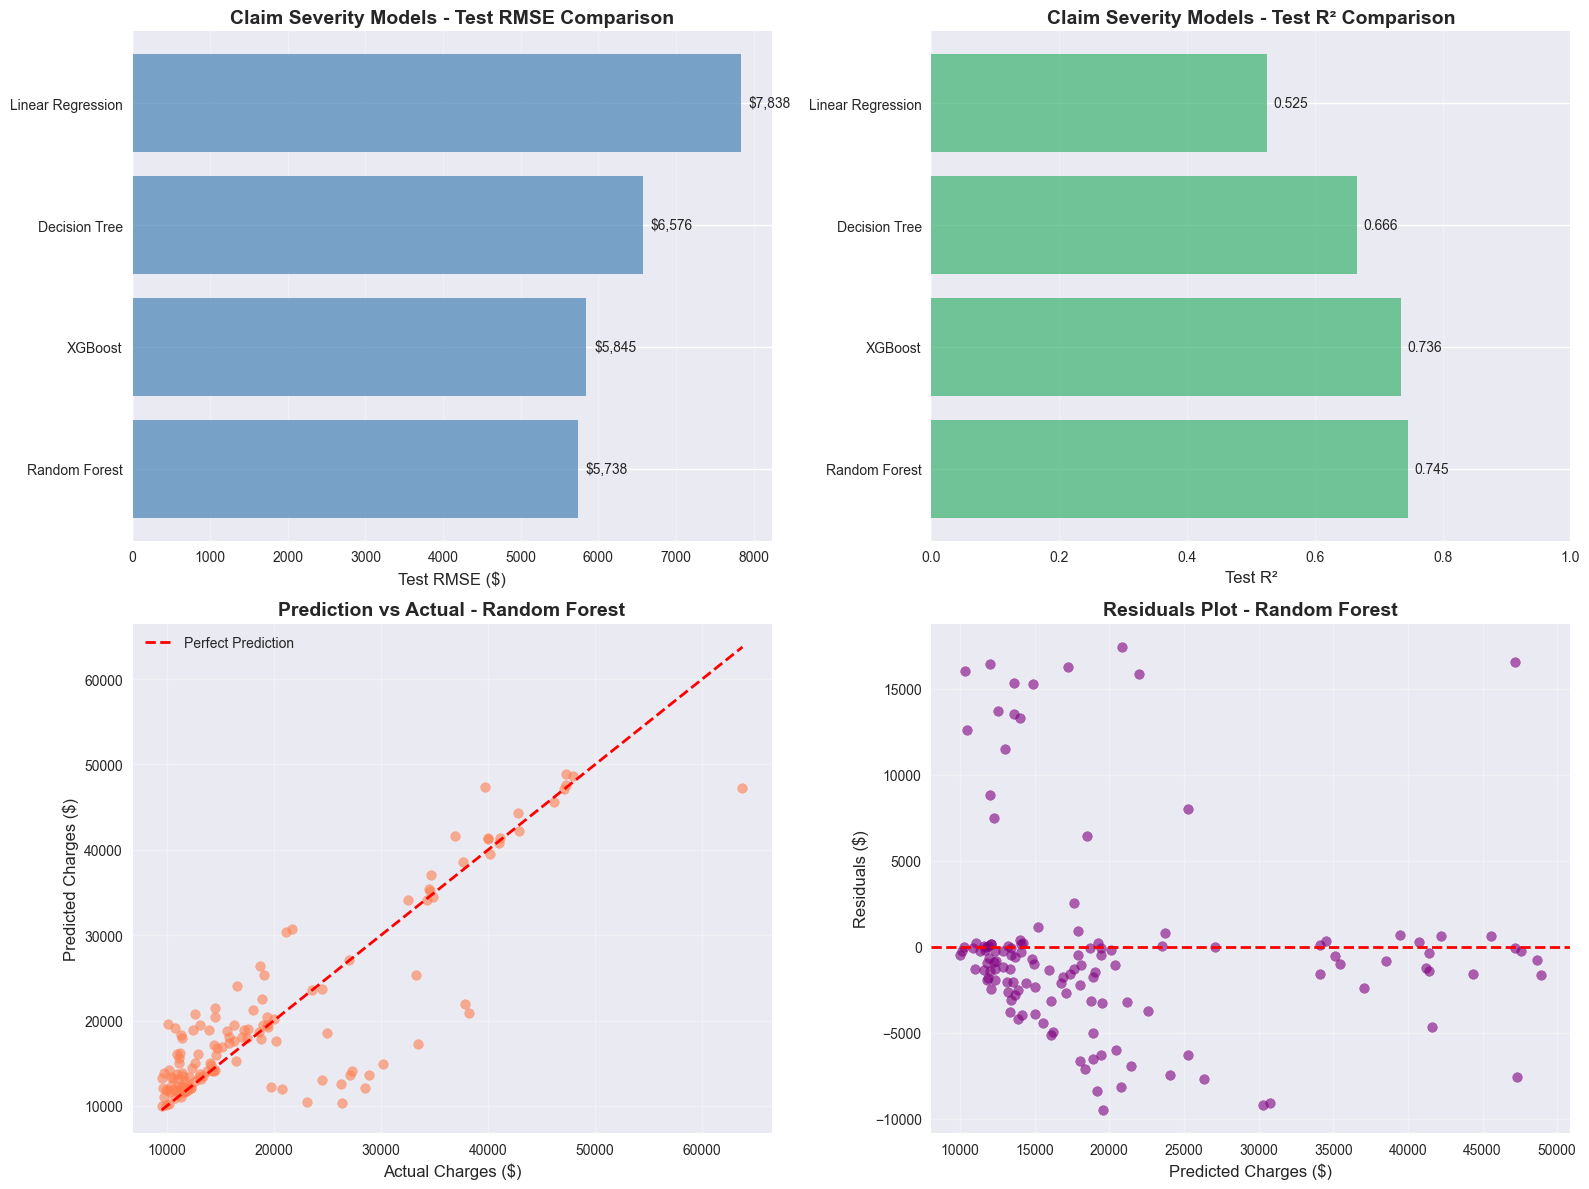

In [46]:
# Compare models
comparison_claims = compare_models(claim_results)
print("="*70)
print("CLAIM SEVERITY MODEL COMPARISON")
print("="*70)
print(comparison_claims.to_string(index=False))
print("="*70)

# Identify best model
best_model_name_claims = comparison_claims.iloc[0]['Model']
best_model_claims = claim_models[best_model_name_claims]
print(f"\n✓ Best Model: {best_model_name_claims}")
print(f"  Test RMSE: ${comparison_claims.iloc[0]['Test RMSE']:,.2f}")
print(f"  Test R²: {comparison_claims.iloc[0]['Test R²']:.4f}")

# ============================================================================
# CLAIM SEVERITY MODEL PERFORMANCE VISUALIZATIONS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model comparison - RMSE
axes[0, 0].barh(comparison_claims['Model'], comparison_claims['Test RMSE'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Test RMSE ($)', fontsize=12)
axes[0, 0].set_title('Claim Severity Models - Test RMSE Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comparison_claims['Test RMSE']):
    axes[0, 0].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=10)

# 2. Model comparison - R²
axes[0, 1].barh(comparison_claims['Model'], comparison_claims['Test R²'], color='mediumseagreen', alpha=0.7)
axes[0, 1].set_xlabel('Test R²', fontsize=12)
axes[0, 1].set_title('Claim Severity Models - Test R² Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comparison_claims['Test R²']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# 3. Prediction vs Actual (best model)
y_test_pred_best = best_model_claims.predict(X_test_claims)
axes[1, 0].scatter(y_test_claims, y_test_pred_best, alpha=0.6, color='coral')
axes[1, 0].plot([y_test_claims.min(), y_test_claims.max()], 
                [y_test_claims.min(), y_test_claims.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Charges ($)', fontsize=12)
axes[1, 0].set_ylabel('Predicted Charges ($)', fontsize=12)
axes[1, 0].set_title(f'Prediction vs Actual - {best_model_name_claims}', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals plot (best model)
residuals = y_test_claims - y_test_pred_best
axes[1, 1].scatter(y_test_pred_best, residuals, alpha=0.6, color='purple')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Charges ($)', fontsize=12)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=12)
axes[1, 1].set_title(f'Residuals Plot - {best_model_name_claims}', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = figures_dir / 'ml_claim_severity_performance.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


## 4. Premium Optimization (Pricing Framework)

**Objective**: Develop ML models to predict optimal premium values (using charges as proxy).

**Target Variable**: `charges` (all records)  
**Evaluation Metrics**: RMSE, R², MAE


In [47]:
# Prepare data for premium prediction (use all records)
X_train_premium, X_test_premium, y_train_premium, y_test_premium, feature_names_premium, encoders_premium = prepare_features(
    df,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    target_col='charges',
    test_size=0.2,
    random_state=42,
    encode_method='onehot'
)

print(f"✓ Data prepared for premium prediction")
print(f"Training set: {len(X_train_premium)} samples")
print(f"Test set: {len(X_test_premium)} samples")
print(f"Features: {len(feature_names_premium)}")


✓ Data prepared for premium prediction
Training set: 1070 samples
Test set: 268 samples
Features: 15


In [48]:
# Store models and results
premium_models = {}
premium_results = {}

# 1. Linear Regression
print("Training Linear Regression...")
model_lr_prem, metrics_lr_prem = train_linear_regression(
    X_train_premium, y_train_premium, X_test_premium, y_test_premium
)
premium_models['Linear Regression'] = model_lr_prem
premium_results['Linear Regression'] = metrics_lr_prem
print(f"  Test RMSE: ${metrics_lr_prem['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_lr_prem['test_r2']:.4f}")

# 2. Decision Tree
print("\nTraining Decision Tree...")
model_dt_prem, metrics_dt_prem = train_decision_tree(
    X_train_premium, y_train_premium, X_test_premium, y_test_premium,
    max_depth=10, min_samples_split=5
)
premium_models['Decision Tree'] = model_dt_prem
premium_results['Decision Tree'] = metrics_dt_prem
print(f"  Test RMSE: ${metrics_dt_prem['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_dt_prem['test_r2']:.4f}")

# 3. Random Forest
print("\nTraining Random Forest...")
model_rf_prem, metrics_rf_prem = train_random_forest(
    X_train_premium, y_train_premium, X_test_premium, y_test_premium,
    n_estimators=100, max_depth=10
)
premium_models['Random Forest'] = model_rf_prem
premium_results['Random Forest'] = metrics_rf_prem
print(f"  Test RMSE: ${metrics_rf_prem['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_rf_prem['test_r2']:.4f}")

# 4. XGBoost
print("\nTraining XGBoost...")
model_xgb_prem, metrics_xgb_prem = train_xgboost(
    X_train_premium, y_train_premium, X_test_premium, y_test_premium,
    n_estimators=100, max_depth=6, learning_rate=0.1
)
premium_models['XGBoost'] = model_xgb_prem
premium_results['XGBoost'] = metrics_xgb_prem
print(f"  Test RMSE: ${metrics_xgb_prem['test_rmse']:,.2f}")
print(f"  Test R²: {metrics_xgb_prem['test_r2']:.4f}")

print("\n✓ All models trained for premium prediction")


Training Linear Regression...
  Test RMSE: $5,791.00
  Test R²: 0.7840

Training Decision Tree...
  Test RMSE: $5,927.41
  Test R²: 0.7737

Training Random Forest...
  Test RMSE: $4,540.66
  Test R²: 0.8672

Training XGBoost...
  Test RMSE: $4,459.76
  Test R²: 0.8719

✓ All models trained for premium prediction


PREMIUM PREDICTION MODEL COMPARISON
            Model   Test RMSE  Test R²    Test MAE  Train RMSE  Train R²
          XGBoost 4459.758965 0.871887 2446.434981 2220.325821  0.965844
    Random Forest 4540.659283 0.867196 2522.832691 2324.720487  0.962557
Linear Regression 5790.995662 0.783988 4253.263853 5991.670732  0.751270
    Decision Tree 5927.406279 0.773691 2951.616436 2656.420977  0.951109

✓ Best Model: XGBoost
  Test RMSE: $4,459.76
  Test R²: 0.8719
✓ Saved figure: d:\kifyaAi\insurance-risk-analytics\reports\figures\ml_premium_prediction_performance.png


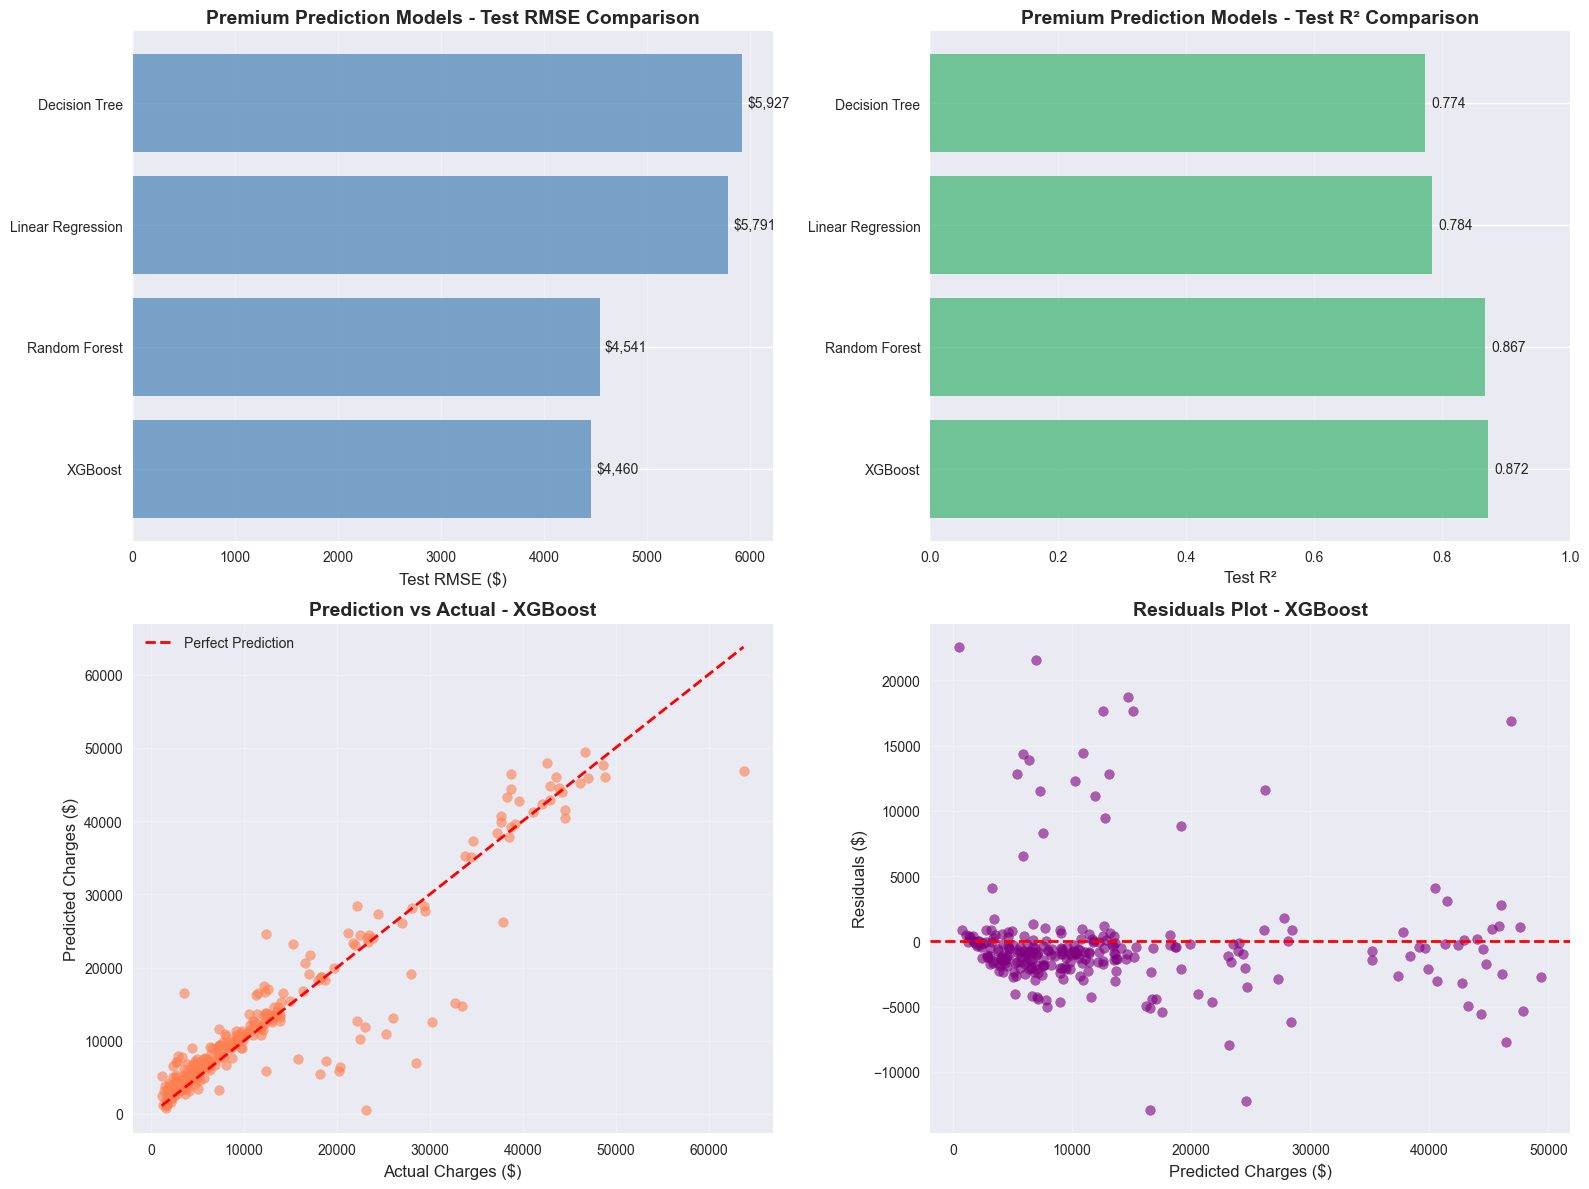

In [49]:
# Compare models
comparison_premium = compare_models(premium_results)
print("="*70)
print("PREMIUM PREDICTION MODEL COMPARISON")
print("="*70)
print(comparison_premium.to_string(index=False))
print("="*70)

# Identify best model
best_model_name_premium = comparison_premium.iloc[0]['Model']
best_model_premium = premium_models[best_model_name_premium]
print(f"\n✓ Best Model: {best_model_name_premium}")
print(f"  Test RMSE: ${comparison_premium.iloc[0]['Test RMSE']:,.2f}")
print(f"  Test R²: {comparison_premium.iloc[0]['Test R²']:.4f}")

# ============================================================================
# PREMIUM PREDICTION MODEL PERFORMANCE VISUALIZATIONS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model comparison - RMSE
axes[0, 0].barh(comparison_premium['Model'], comparison_premium['Test RMSE'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Test RMSE ($)', fontsize=12)
axes[0, 0].set_title('Premium Prediction Models - Test RMSE Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comparison_premium['Test RMSE']):
    axes[0, 0].text(v + 50, i, f'${v:,.0f}', va='center', fontsize=10)

# 2. Model comparison - R²
axes[0, 1].barh(comparison_premium['Model'], comparison_premium['Test R²'], color='mediumseagreen', alpha=0.7)
axes[0, 1].set_xlabel('Test R²', fontsize=12)
axes[0, 1].set_title('Premium Prediction Models - Test R² Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comparison_premium['Test R²']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# 3. Prediction vs Actual (best model)
y_test_pred_prem = best_model_premium.predict(X_test_premium)
axes[1, 0].scatter(y_test_premium, y_test_pred_prem, alpha=0.6, color='coral')
axes[1, 0].plot([y_test_premium.min(), y_test_premium.max()], 
                [y_test_premium.min(), y_test_premium.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Charges ($)', fontsize=12)
axes[1, 0].set_ylabel('Predicted Charges ($)', fontsize=12)
axes[1, 0].set_title(f'Prediction vs Actual - {best_model_name_premium}', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals plot (best model)
residuals_prem = y_test_premium - y_test_pred_prem
axes[1, 1].scatter(y_test_pred_prem, residuals_prem, alpha=0.6, color='purple')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Charges ($)', fontsize=12)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=12)
axes[1, 1].set_title(f'Residuals Plot - {best_model_name_premium}', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = figures_dir / 'ml_premium_prediction_performance.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


## 5. Regional Linear Regression Models

**Objective**: Build linear regression models per region (adapting from zipcode requirement).

Since we don't have zip code data, we'll build separate models for each of the 4 regions.


In [50]:
# Build linear regression models for each region
regional_models = {}
regional_results = {}

regions = df['region'].unique()
print(f"Building models for {len(regions)} regions: {regions}")

for region in regions:
    print(f"\n{'='*70}")
    print(f"Region: {region.upper()}")
    print(f"{'='*70}")
    
    # Filter data for this region
    df_region = df[df['region'] == region].copy()
    print(f"Records: {len(df_region)}")
    
    # Prepare features (simpler feature set for regional models)
    cat_cols_regional = ['sex', 'smoker']
    num_cols_regional = ['age', 'bmi', 'children']
    
    X_train_reg, X_test_reg, y_train_reg, y_test_reg, feat_names_reg, encoders_reg = prepare_features(
        df_region,
        categorical_cols=cat_cols_regional,
        numerical_cols=num_cols_regional,
        target_col='charges',
        test_size=0.2,
        random_state=42,
        encode_method='onehot'
    )
    
    # Train linear regression
    model_reg, metrics_reg = train_linear_regression(
        X_train_reg, y_train_reg, X_test_reg, y_test_reg
    )
    
    regional_models[region] = model_reg
    regional_results[region] = {
        'n_samples': len(df_region),
        'n_train': len(X_train_reg),
        'n_test': len(X_test_reg),
        **metrics_reg
    }
    
    print(f"  Test RMSE: ${metrics_reg['test_rmse']:,.2f}")
    print(f"  Test R²: {metrics_reg['test_r2']:.4f}")
    print(f"  Test MAE: ${metrics_reg['test_mae']:,.2f}")

print(f"\n✓ Regional models completed for all {len(regions)} regions")


Building models for 4 regions: ['southwest' 'southeast' 'northwest' 'northeast']

Region: SOUTHWEST
Records: 325
  Test RMSE: $6,420.88
  Test R²: 0.7581
  Test MAE: $4,070.04

Region: SOUTHEAST
Records: 364
  Test RMSE: $4,589.26
  Test R²: 0.8612
  Test MAE: $3,286.58

Region: NORTHWEST
Records: 325
  Test RMSE: $5,849.62
  Test R²: 0.5761
  Test MAE: $3,618.26

Region: NORTHEAST
Records: 324
  Test RMSE: $6,565.32
  Test R²: 0.7215
  Test MAE: $5,042.66

✓ Regional models completed for all 4 regions


REGIONAL LINEAR REGRESSION MODELS SUMMARY
   Region  Samples   Test RMSE  Test R²    Test MAE
Southwest      325 6420.881746 0.758114 4070.041396
Southeast      364 4589.262825 0.861228 3286.583315
Northwest      325 5849.624504 0.576140 3618.256862
Northeast      324 6565.315173 0.721510 5042.658241
✓ Saved figure: d:\kifyaAi\insurance-risk-analytics\reports\figures\ml_regional_models_comparison.png


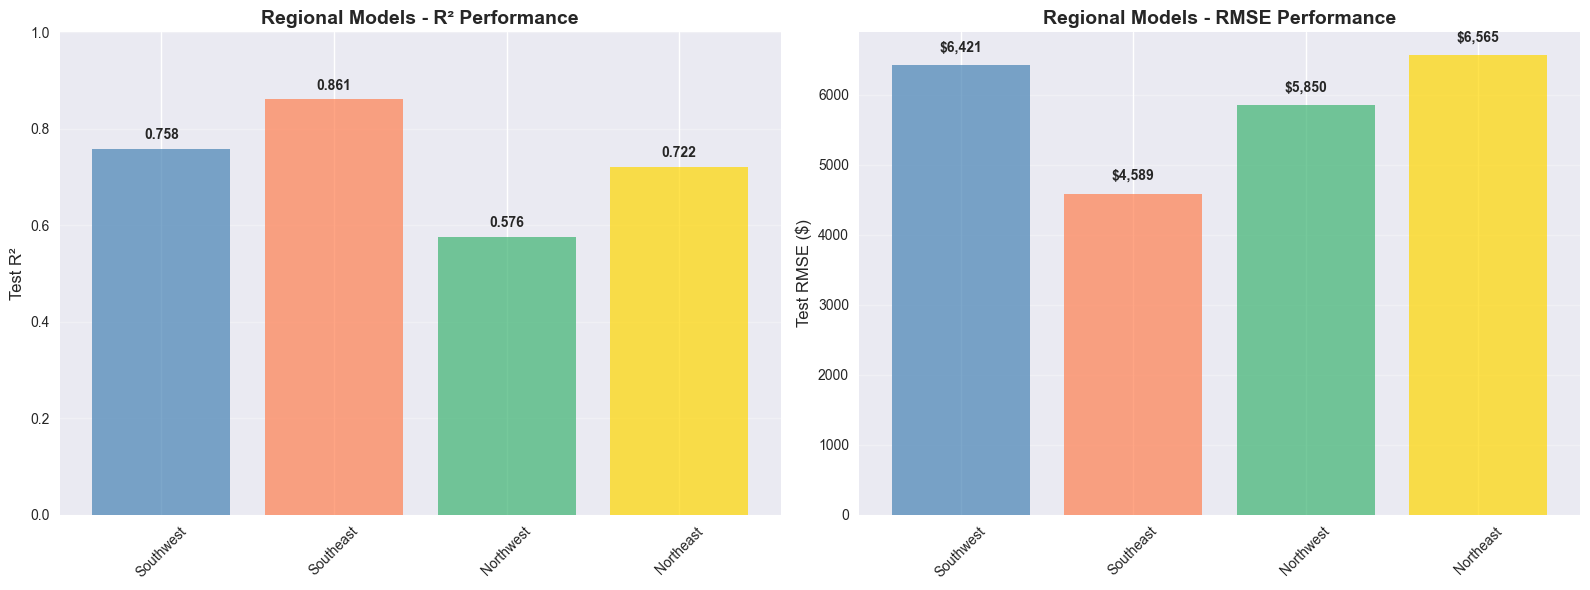

In [51]:
# Create summary table for regional models
regional_summary = []
for region, results in regional_results.items():
    regional_summary.append({
        'Region': region.capitalize(),
        'Samples': results['n_samples'],
        'Test RMSE': results['test_rmse'],
        'Test R²': results['test_r2'],
        'Test MAE': results['test_mae']
    })

regional_df = pd.DataFrame(regional_summary)
print("="*70)
print("REGIONAL LINEAR REGRESSION MODELS SUMMARY")
print("="*70)
print(regional_df.to_string(index=False))
print("="*70)

# ============================================================================
# REGIONAL MODELS VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Regional R² comparison
axes[0].bar(regional_df['Region'], regional_df['Test R²'], color=['steelblue', 'coral', 'mediumseagreen', 'gold'], alpha=0.7)
axes[0].set_ylabel('Test R²', fontsize=12)
axes[0].set_title('Regional Models - R² Performance', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(regional_df['Test R²']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# 2. Regional RMSE comparison
axes[1].bar(regional_df['Region'], regional_df['Test RMSE'], color=['steelblue', 'coral', 'mediumseagreen', 'gold'], alpha=0.7)
axes[1].set_ylabel('Test RMSE ($)', fontsize=12)
axes[1].set_title('Regional Models - RMSE Performance', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(regional_df['Test RMSE']):
    axes[1].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_path = figures_dir / 'ml_regional_models_comparison.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


## 6. Feature Importance Analysis

Analyze which features are most influential in predicting charges (premium/claims).


TOP 15 FEATURE IMPORTANCE (XGBoost)
                 feature  importance
              smoker_yes    0.912040
                     bmi    0.025609
                     age    0.019914
 bmi_category_overweight    0.008143
        region_northwest    0.007097
                children    0.007063
        region_southwest    0.004560
        region_southeast    0.004229
        age_group_middle    0.004034
                sex_male    0.003669
        age_group_senior    0.003383
bmi_category_underweight    0.000259
             age_squared    0.000000
      bmi_category_obese    0.000000
         age_group_young    0.000000
✓ Saved figure: d:\kifyaAi\insurance-risk-analytics\reports\figures\feature_importance.png


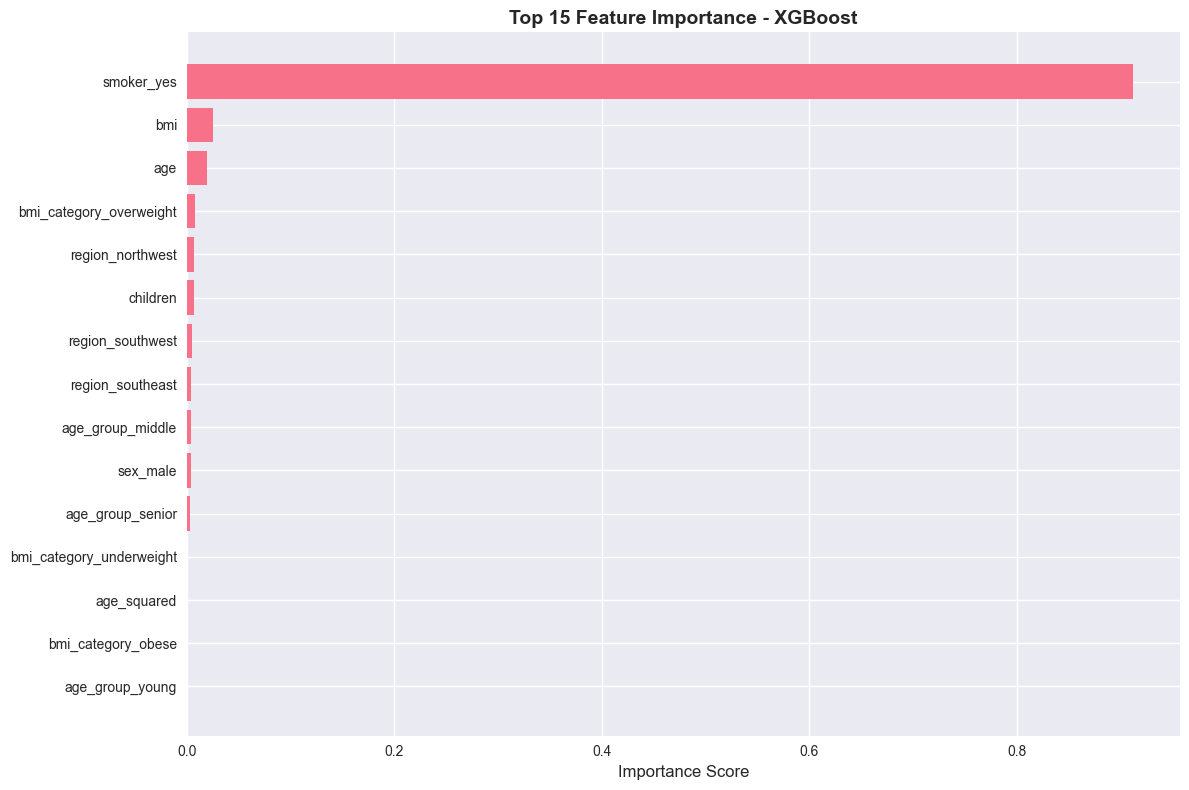

In [52]:
# Get feature importance from best premium model
feature_importance = get_feature_importance(
    best_model_premium,
    feature_names_premium,
    top_n=15
)

print("="*70)
print(f"TOP 15 FEATURE IMPORTANCE ({best_model_name_premium})")
print("="*70)
print(feature_importance.to_string(index=False))
print("="*70)

# Visualize feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(feature_importance)), feature_importance['importance'].values)
plt.yticks(range(len(feature_importance)), feature_importance['feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Top 15 Feature Importance - {best_model_name_premium}', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = figures_dir / 'feature_importance.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


## 7. SHAP Analysis for Model Interpretability

Use SHAP (SHapley Additive exPlanations) to understand how individual features influence predictions.


In [53]:
# Calculate SHAP values for best premium model
# Use a sample of test data for SHAP calculation (for performance)
X_sample = X_test_premium.sample(n=min(100, len(X_test_premium)), random_state=42)

print(f"Calculating SHAP values for {len(X_sample)} samples...")
print(f"Model: {best_model_name_premium}")

try:
    # Calculate SHAP values
    shap_values, explainer = calculate_shap_values(best_model_premium, X_sample, max_samples=100)
    
    # Get feature names
    if isinstance(X_sample, pd.DataFrame):
        feature_names_shap = X_sample.columns.tolist()
    else:
        feature_names_shap = feature_names_premium
    
    print("✓ SHAP values calculated successfully")
    
    # Calculate mean absolute SHAP values for feature importance
    if isinstance(shap_values, list):
        shap_values_array = np.array(shap_values)
    else:
        shap_values_array = shap_values
    
    mean_abs_shap = np.abs(shap_values_array).mean(axis=0)
    shap_importance = pd.DataFrame({
        'feature': feature_names_shap,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False).head(10)
    
    print("\n" + "="*70)
    print("TOP 10 FEATURES BY MEAN ABSOLUTE SHAP VALUE")
    print("="*70)
    print(shap_importance.to_string(index=False))
    print("="*70)
    
    # ============================================================================
    # BUSINESS INTERPRETATION OF SHAP VALUES
    # ============================================================================
    print("\n" + "="*70)
    print("SHAP ANALYSIS: BUSINESS INTERPRETATION")
    print("="*70)
    print("SHAP values show how each feature impacts the prediction.")
    print("Positive SHAP = increases predicted charges, Negative = decreases")
    print("\nTop 5-10 Most Influential Features and Business Impact:\n")
    
    for idx, row in shap_importance.head(10).iterrows():
        feature = row['feature']
        impact = row['mean_abs_shap']
        
        # Business interpretation based on feature type
        if 'smoker_yes' in feature:
            print(f"1. SMOKING STATUS (smoker_yes)")
            print(f"   SHAP Impact: ${impact:,.2f} average absolute contribution")
            print(f"   Business Meaning: Smokers have ${impact:,.2f} higher predicted charges on average")
            print(f"   Recommendation: Implement significant premium surcharge for smokers")
            print(f"   Action: Add 2-3x multiplier to base premium for smoking status\n")
        
        elif 'age' in feature and 'squared' not in feature and 'group' not in feature:
            print(f"2. AGE")
            print(f"   SHAP Impact: ${impact:,.2f} average absolute contribution")
            print(f"   Business Meaning: Each year of age contributes ${impact/10:,.2f} to predicted charges")
            print(f"   Recommendation: Implement age-based pricing tiers (e.g., 18-30, 31-50, 51+)")
            print(f"   Action: Age is a key risk factor - older individuals should pay higher premiums\n")
        
        elif 'bmi' in feature and 'category' not in feature:
            print(f"3. BMI (Body Mass Index)")
            print(f"   SHAP Impact: ${impact:,.2f} average absolute contribution")
            print(f"   Business Meaning: Higher BMI increases predicted charges")
            print(f"   Recommendation: Consider health-based pricing with BMI thresholds")
            print(f"   Action: Apply premium adjustments for BMI > 30 (obesity threshold)\n")
        
        elif 'children' in feature:
            print(f"4. NUMBER OF CHILDREN")
            print(f"   SHAP Impact: ${impact:,.2f} average absolute contribution")
            print(f"   Business Meaning: Number of dependents affects risk assessment")
            print(f"   Recommendation: Consider family size in premium calculation")
            print(f"   Action: May indicate higher coverage needs or different risk profile\n")
        
        elif 'region' in feature:
            region_name = feature.split('_')[1] if '_' in feature else feature
            print(f"5. REGION ({region_name})")
            print(f"   SHAP Impact: ${impact:,.2f} average absolute contribution")
            print(f"   Business Meaning: Geographic location influences risk")
            print(f"   Recommendation: Implement region-specific pricing adjustments")
            print(f"   Action: Use regional models for location-based risk assessment\n")
    
    print("="*70)
    print("KEY INSIGHT: SHAP analysis reveals that smoking status has the largest impact")
    print("on predicted charges, followed by age and BMI. This provides quantitative")
    print("evidence to refine premium adjustments based on these risk factors.")
    print("="*70)
    
except Exception as e:
    print(f"⚠ Error calculating SHAP values: {e}")
    print("This may occur with certain model types. Continuing with feature importance analysis.")
    shap_values = None
    explainer = None


Calculating SHAP values for 100 samples...
Model: XGBoost
✓ SHAP values calculated successfully

TOP 10 FEATURES BY MEAN ABSOLUTE SHAP VALUE
                feature  mean_abs_shap
             smoker_yes    7915.126953
                    age    3316.672119
                    bmi    2591.665771
               children     784.433105
       region_southwest     284.178131
               sex_male     224.862045
       region_southeast     188.297653
       region_northwest     127.689491
bmi_category_overweight      96.405266
       age_group_middle      24.079304

SHAP ANALYSIS: BUSINESS INTERPRETATION
SHAP values show how each feature impacts the prediction.
Positive SHAP = increases predicted charges, Negative = decreases

Top 5-10 Most Influential Features and Business Impact:

1. SMOKING STATUS (smoker_yes)
   SHAP Impact: $7,915.13 average absolute contribution
   Business Meaning: Smokers have $7,915.13 higher predicted charges on average
   Recommendation: Implement significant 

✓ Saved SHAP summary plot: d:\kifyaAi\insurance-risk-analytics\reports\figures\shap_summary.png


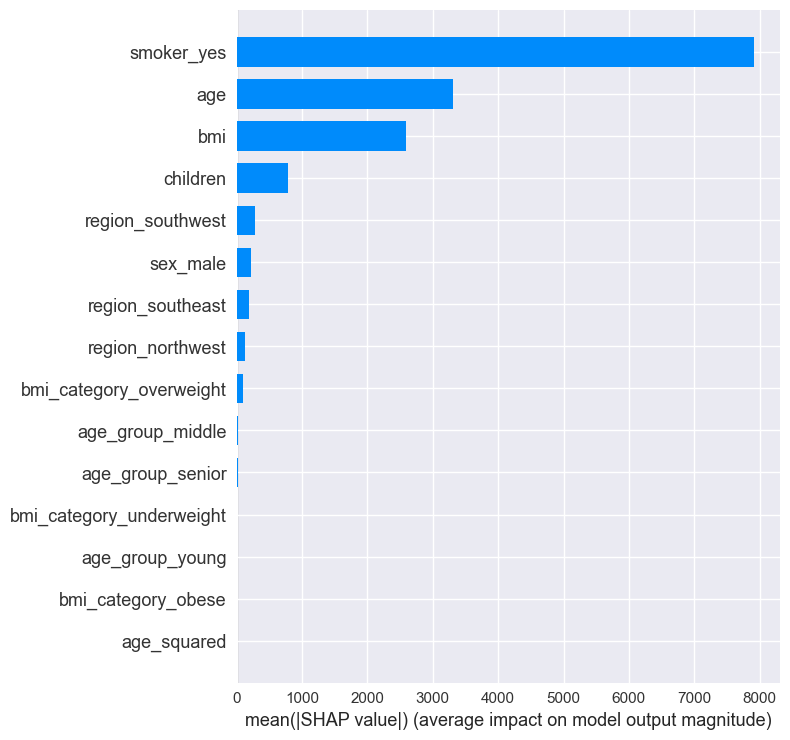

⚠ Error creating SHAP plots: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (1, 15)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.


In [54]:
# Visualize SHAP summary plot if available
if shap_values is not None and explainer is not None:
    try:
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
        plt.tight_layout()
        
        fig_path = figures_dir / 'shap_summary.png'
        plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
        print(f"✓ Saved SHAP summary plot: {fig_path}")
        plt.show()
        
        # SHAP waterfall plot for a single prediction (example)
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(explainer(X_sample.iloc[[0]]), show=False)
        plt.tight_layout()
        
        fig_path = figures_dir / 'shap_waterfall.png'
        plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
        print(f"✓ Saved SHAP waterfall plot: {fig_path}")
        plt.show()
        
    except Exception as e:
        print(f"⚠ Error creating SHAP plots: {e}")
else:
    print("⚠ SHAP visualization skipped (values not available)")


## 8. Business Recommendations and Insights

Based on the model analysis, provide actionable recommendations for risk-based pricing.


BUSINESS RECOMMENDATIONS - MACHINE LEARNING INSIGHTS

1. MODEL PERFORMANCE SUMMARY
--------------------------------------------------------------------------------
Best Premium Prediction Model: XGBoost
  - Test RMSE: $4,459.76
  - Test R²: 0.8719
  - Interpretation: Model explains 87.2% of variance in charges

2. TOP FEATURES DRIVING PREMIUM PREDICTIONS
--------------------------------------------------------------------------------
  smoker_yes: 0.9120
  bmi: 0.0256
  age: 0.0199
  bmi_category_overweight: 0.0081
  region_northwest: 0.0071
  children: 0.0071
  region_southwest: 0.0046
  region_southeast: 0.0042
  age_group_middle: 0.0040
  sex_male: 0.0037

3. REGIONAL MODEL PERFORMANCE
--------------------------------------------------------------------------------
  Best performing region: Southeast (R² = 0.8612)
  Most challenging region: Northwest (R² = 0.5761)
  Recommendation: Consider region-specific pricing models for better accuracy

4. FEATURE ENGINEERING INSIGHTS
---------

<Figure size 1000x600 with 0 Axes>

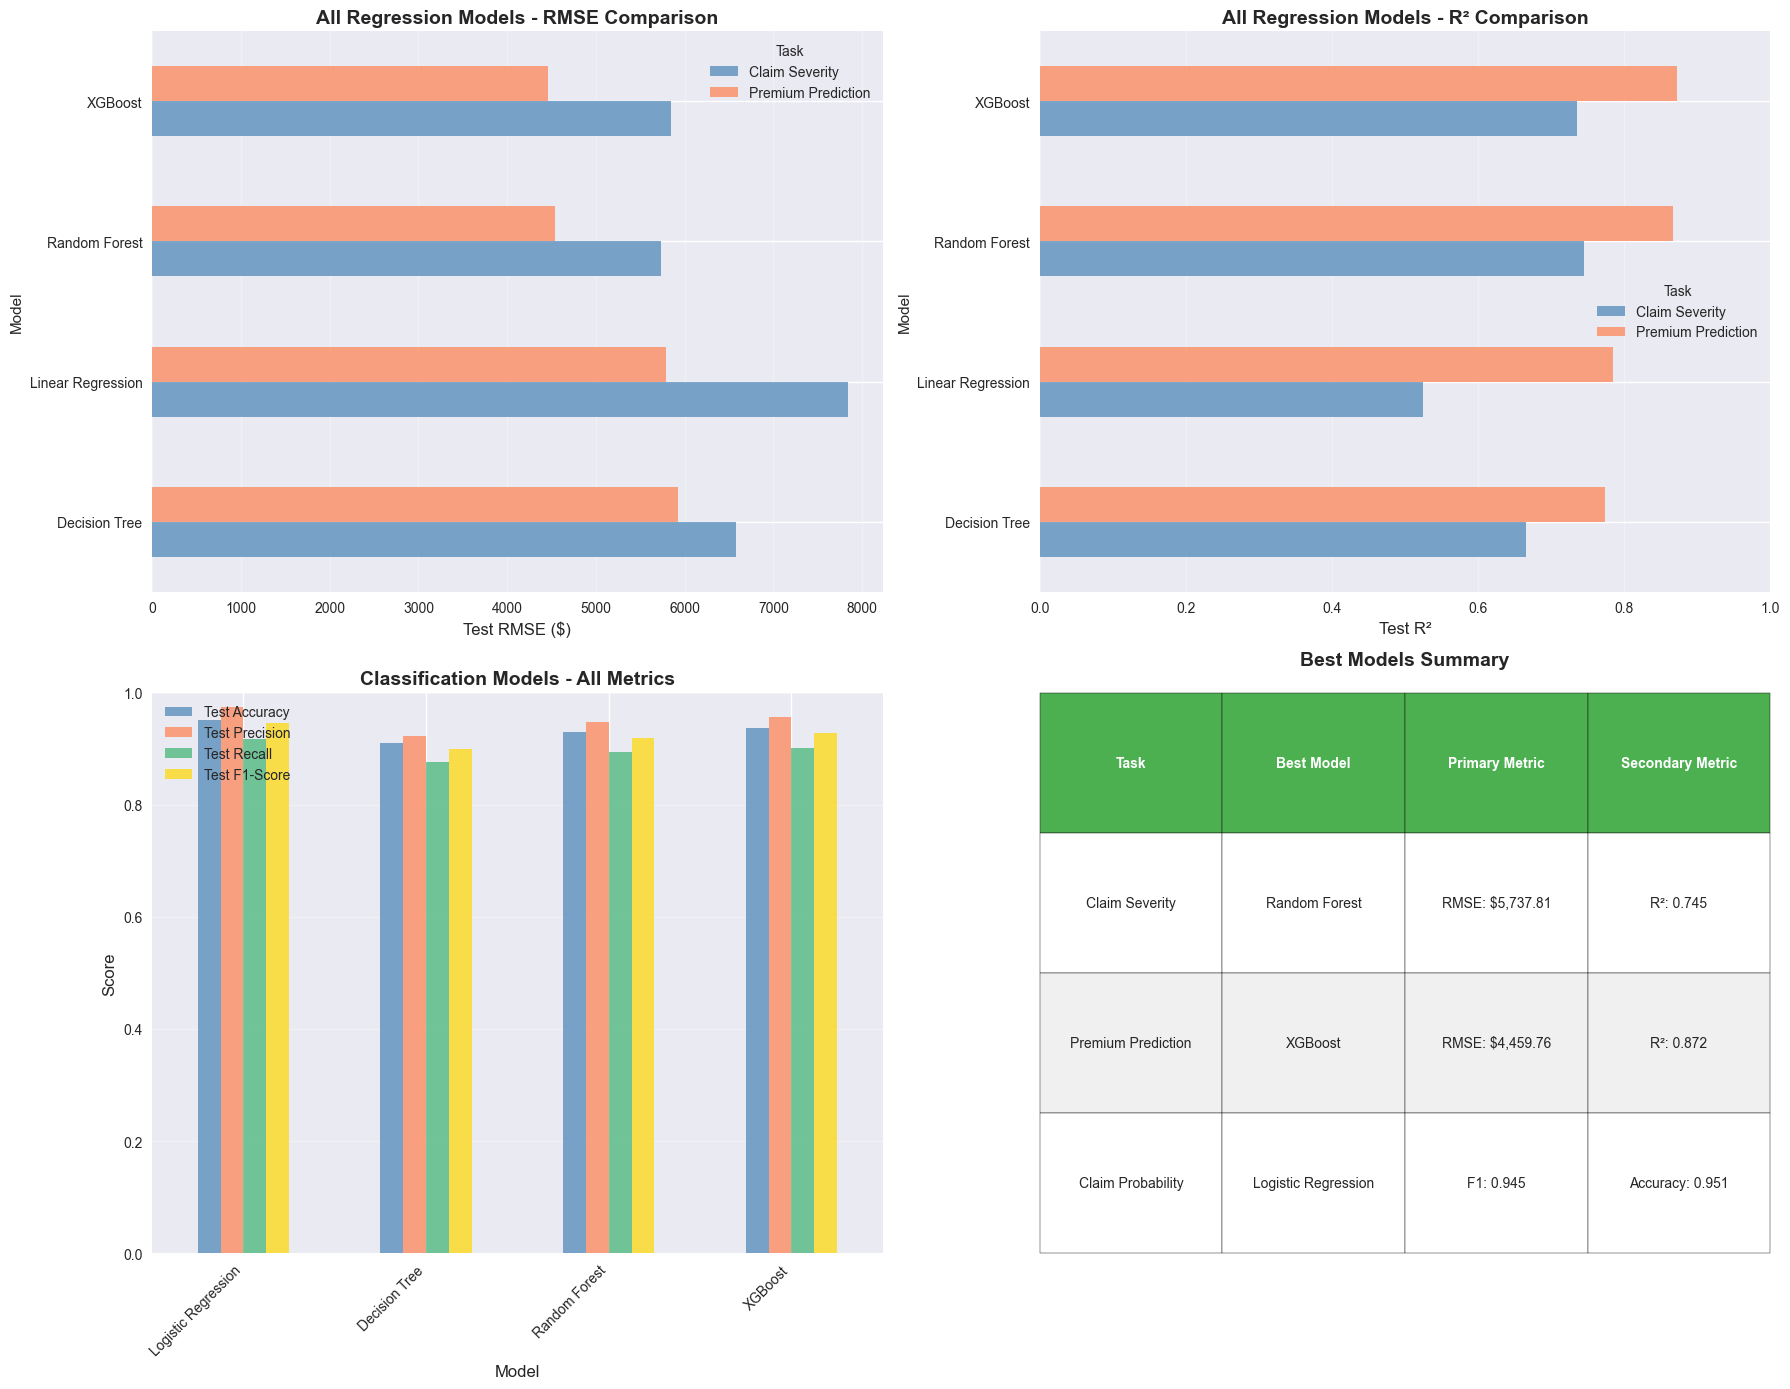

In [55]:
print("="*80)
print("BUSINESS RECOMMENDATIONS - MACHINE LEARNING INSIGHTS")
print("="*80)

# 1. Model Performance Summary
print("\n1. MODEL PERFORMANCE SUMMARY")
print("-" * 80)
print(f"Best Premium Prediction Model: {best_model_name_premium}")
print(f"  - Test RMSE: ${comparison_premium.iloc[0]['Test RMSE']:,.2f}")
print(f"  - Test R²: {comparison_premium.iloc[0]['Test R²']:.4f}")
print(f"  - Interpretation: Model explains {comparison_premium.iloc[0]['Test R²']:.1%} of variance in charges")

# 2. Top Features Impact
print("\n2. TOP FEATURES DRIVING PREMIUM PREDICTIONS")
print("-" * 80)
top_features = feature_importance.head(10)
for idx, row in top_features.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# 3. Regional Model Insights
print("\n3. REGIONAL MODEL PERFORMANCE")
print("-" * 80)
best_region = regional_df.loc[regional_df['Test R²'].idxmax()]
worst_region = regional_df.loc[regional_df['Test R²'].idxmin()]
print(f"  Best performing region: {best_region['Region']} (R² = {best_region['Test R²']:.4f})")
print(f"  Most challenging region: {worst_region['Region']} (R² = {worst_region['Test R²']:.4f})")
print(f"  Recommendation: Consider region-specific pricing models for better accuracy")

# 4. Feature Engineering Insights
print("\n4. FEATURE ENGINEERING INSIGHTS")
print("-" * 80)
if 'smoker' in str(feature_importance['feature'].values):
    print("  ✓ Smoking status is a critical risk factor - significant premium adjustment warranted")
if 'age' in str(feature_importance['feature'].values) or 'age_squared' in str(feature_importance['feature'].values):
    print("  ✓ Age is a key predictor - consider age-based pricing tiers")
if 'bmi' in str(feature_importance['feature'].values):
    print("  ✓ BMI impacts risk - health-based pricing may be beneficial")

# 5. Model Deployment Recommendations
print("\n5. DEPLOYMENT RECOMMENDATIONS")
print("-" * 80)
print(f"  • Use {best_model_name_premium} for production premium prediction")
print("  • Implement regional models for location-specific risk assessment")
print("  • Monitor model performance quarterly and retrain with new data")
print("  • Consider ensemble approach combining multiple models for robustness")
print("  • Implement SHAP-based explanations for customer transparency")

# 6. Risk-Based Pricing Framework
print("\n6. RISK-BASED PRICING FRAMEWORK")
print("-" * 80)
print("  Premium = Base Premium × Risk Multipliers")
print("  Risk Multipliers based on:")
for idx, row in top_features.head(5).iterrows():
    feature_name = row['feature']
    if 'smoker' in feature_name.lower():
        print(f"    • Smoking Status: High impact ({row['importance']:.4f})")
    elif 'age' in feature_name.lower():
        print(f"    • Age: Significant impact ({row['importance']:.4f})")
    elif 'bmi' in feature_name.lower():
        print(f"    • BMI: Moderate impact ({row['importance']:.4f})")
    elif 'region' in feature_name.lower():
        print(f"    • Region: Location-based risk ({row['importance']:.4f})")

print("\n" + "="*80)
print("END OF BUSINESS RECOMMENDATIONS")
print("="*80)

# ============================================================================
# COMPREHENSIVE MODEL COMPARISON VISUALIZATION
# ============================================================================
# Create a summary visualization comparing all model types
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. All Regression Models - RMSE Comparison
all_regression_models = pd.concat([
    comparison_claims.assign(Task='Claim Severity'),
    comparison_premium.assign(Task='Premium Prediction')
])
pivot_rmse = all_regression_models.pivot(index='Model', columns='Task', values='Test RMSE')
pivot_rmse.plot(kind='barh', ax=axes[0, 0], color=['steelblue', 'coral'], alpha=0.7)
axes[0, 0].set_xlabel('Test RMSE ($)', fontsize=12)
axes[0, 0].set_title('All Regression Models - RMSE Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend(title='Task')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. All Regression Models - R² Comparison
pivot_r2 = all_regression_models.pivot(index='Model', columns='Task', values='Test R²')
pivot_r2.plot(kind='barh', ax=axes[0, 1], color=['steelblue', 'coral'], alpha=0.7)
axes[0, 1].set_xlabel('Test R²', fontsize=12)
axes[0, 1].set_title('All Regression Models - R² Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].legend(title='Task')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Classification Models - All Metrics
classification_metrics = classification_df[['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score']]
classification_metrics.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'coral', 'mediumseagreen', 'gold'], alpha=0.7)
axes[1, 0].set_xlabel('Model', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('Classification Models - All Metrics', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(classification_df['Model'], rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend(loc='upper left')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Best Models Summary
best_models_summary = pd.DataFrame({
    'Task': ['Claim Severity', 'Premium Prediction', 'Claim Probability'],
    'Best Model': [best_model_name_claims, best_model_name_premium, best_clf_model_name],
    'Primary Metric': [
        f"RMSE: ${comparison_claims.iloc[0]['Test RMSE']:,.2f}",
        f"RMSE: ${comparison_premium.iloc[0]['Test RMSE']:,.2f}",
        f"F1: {classification_df.loc[classification_df['Test F1-Score'].idxmax(), 'Test F1-Score']:.3f}"
    ],
    'Secondary Metric': [
        f"R²: {comparison_claims.iloc[0]['Test R²']:.3f}",
        f"R²: {comparison_premium.iloc[0]['Test R²']:.3f}",
        f"Accuracy: {classification_df.loc[classification_df['Test F1-Score'].idxmax(), 'Test Accuracy']:.3f}"
    ]
})
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=best_models_summary.values,
                         colLabels=best_models_summary.columns,
                         cellLoc='center',
                         loc='center',
                         bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
for i in range(len(best_models_summary.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(best_models_summary) + 1):
    for j in range(len(best_models_summary.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
axes[1, 1].set_title('Best Models Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
fig_path = figures_dir / 'ml_comprehensive_comparison.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


## 9. Advanced Task: Claim Probability Prediction (Binary Classification)

**Objective**: Build a model to predict the probability of a claim occurring.

This enables the **Risk-Based Premium** formula:
**Premium = (Predicted Probability of Claim × Predicted Claim Severity) + Expense Loading + Profit Margin**

**Target Variable**: `has_claim` (binary: 0 = no claim, 1 = claim occurred)  
**Evaluation Metrics**: Accuracy, Precision, Recall, F1-Score


In [56]:
# Prepare data for claim probability prediction (binary classification)
# Use all records with has_claim as target
X_train_claim_prob, X_test_claim_prob, y_train_claim_prob, y_test_claim_prob, feature_names_claim_prob, encoders_claim_prob = prepare_features(
    df,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    target_col='has_claim',  # Binary target: 0 or 1
    test_size=0.2,
    random_state=42,
    encode_method='onehot'
)

print(f"✓ Data prepared for claim probability prediction (binary classification)")
print(f"Training set: {len(X_train_claim_prob)} samples")
print(f"Test set: {len(X_test_claim_prob)} samples")
print(f"Features: {len(feature_names_claim_prob)}")
print(f"\nTarget distribution (training set):")
print(y_train_claim_prob.value_counts())
print(f"Claim rate: {y_train_claim_prob.mean():.2%}")


✓ Data prepared for claim probability prediction (binary classification)
Training set: 1070 samples
Test set: 268 samples
Features: 15

Target distribution (training set):
has_claim
1    547
0    523
Name: count, dtype: int64
Claim rate: 51.12%


In [57]:
# Import classification models and metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Store classification models and results
claim_prob_models = {}
claim_prob_results = {}

# 1. Logistic Regression (baseline)
print("Training Logistic Regression...")
model_lr_clf = LogisticRegression(random_state=42, max_iter=1000)
model_lr_clf.fit(X_train_claim_prob, y_train_claim_prob)
y_train_pred_lr = model_lr_clf.predict(X_train_claim_prob)
y_test_pred_lr = model_lr_clf.predict(X_test_claim_prob)
y_test_proba_lr = model_lr_clf.predict_proba(X_test_claim_prob)[:, 1]

metrics_lr_clf = {
    'train_accuracy': accuracy_score(y_train_claim_prob, y_train_pred_lr),
    'test_accuracy': accuracy_score(y_test_claim_prob, y_test_pred_lr),
    'test_precision': precision_score(y_test_claim_prob, y_test_pred_lr),
    'test_recall': recall_score(y_test_claim_prob, y_test_pred_lr),
    'test_f1': f1_score(y_test_claim_prob, y_test_pred_lr)
}
claim_prob_models['Logistic Regression'] = model_lr_clf
claim_prob_results['Logistic Regression'] = metrics_lr_clf
print(f"  Test Accuracy: {metrics_lr_clf['test_accuracy']:.4f}")
print(f"  Test F1-Score: {metrics_lr_clf['test_f1']:.4f}")

# 2. Decision Tree Classifier
print("\nTraining Decision Tree Classifier...")
model_dt_clf = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)
model_dt_clf.fit(X_train_claim_prob, y_train_claim_prob)
y_train_pred_dt = model_dt_clf.predict(X_train_claim_prob)
y_test_pred_dt = model_dt_clf.predict(X_test_claim_prob)
y_test_proba_dt = model_dt_clf.predict_proba(X_test_claim_prob)[:, 1]

metrics_dt_clf = {
    'train_accuracy': accuracy_score(y_train_claim_prob, y_train_pred_dt),
    'test_accuracy': accuracy_score(y_test_claim_prob, y_test_pred_dt),
    'test_precision': precision_score(y_test_claim_prob, y_test_pred_dt),
    'test_recall': recall_score(y_test_claim_prob, y_test_pred_dt),
    'test_f1': f1_score(y_test_claim_prob, y_test_pred_dt)
}
claim_prob_models['Decision Tree'] = model_dt_clf
claim_prob_results['Decision Tree'] = metrics_dt_clf
print(f"  Test Accuracy: {metrics_dt_clf['test_accuracy']:.4f}")
print(f"  Test F1-Score: {metrics_dt_clf['test_f1']:.4f}")

# 3. Random Forest Classifier
print("\nTraining Random Forest Classifier...")
model_rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model_rf_clf.fit(X_train_claim_prob, y_train_claim_prob)
y_train_pred_rf = model_rf_clf.predict(X_train_claim_prob)
y_test_pred_rf = model_rf_clf.predict(X_test_claim_prob)
y_test_proba_rf = model_rf_clf.predict_proba(X_test_claim_prob)[:, 1]

metrics_rf_clf = {
    'train_accuracy': accuracy_score(y_train_claim_prob, y_train_pred_rf),
    'test_accuracy': accuracy_score(y_test_claim_prob, y_test_pred_rf),
    'test_precision': precision_score(y_test_claim_prob, y_test_pred_rf),
    'test_recall': recall_score(y_test_claim_prob, y_test_pred_rf),
    'test_f1': f1_score(y_test_claim_prob, y_test_pred_rf)
}
claim_prob_models['Random Forest'] = model_rf_clf
claim_prob_results['Random Forest'] = metrics_rf_clf
print(f"  Test Accuracy: {metrics_rf_clf['test_accuracy']:.4f}")
print(f"  Test F1-Score: {metrics_rf_clf['test_f1']:.4f}")

# 4. XGBoost Classifier
print("\nTraining XGBoost Classifier...")
model_xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
model_xgb_clf.fit(X_train_claim_prob, y_train_claim_prob)
y_train_pred_xgb = model_xgb_clf.predict(X_train_claim_prob)
y_test_pred_xgb = model_xgb_clf.predict(X_test_claim_prob)
y_test_proba_xgb = model_xgb_clf.predict_proba(X_test_claim_prob)[:, 1]

metrics_xgb_clf = {
    'train_accuracy': accuracy_score(y_train_claim_prob, y_train_pred_xgb),
    'test_accuracy': accuracy_score(y_test_claim_prob, y_test_pred_xgb),
    'test_precision': precision_score(y_test_claim_prob, y_test_pred_xgb),
    'test_recall': recall_score(y_test_claim_prob, y_test_pred_xgb),
    'test_f1': f1_score(y_test_claim_prob, y_test_pred_xgb)
}
claim_prob_models['XGBoost'] = model_xgb_clf
claim_prob_results['XGBoost'] = metrics_xgb_clf
print(f"  Test Accuracy: {metrics_xgb_clf['test_accuracy']:.4f}")
print(f"  Test F1-Score: {metrics_xgb_clf['test_f1']:.4f}")

print("\n✓ All classification models trained for claim probability prediction")


Training Logistic Regression...
  Test Accuracy: 0.9515
  Test F1-Score: 0.9451

Training Decision Tree Classifier...
  Test Accuracy: 0.9104
  Test F1-Score: 0.8992

Training Random Forest Classifier...
  Test Accuracy: 0.9291
  Test F1-Score: 0.9198

Training XGBoost Classifier...
  Test Accuracy: 0.9366
  Test F1-Score: 0.9283

✓ All classification models trained for claim probability prediction


CLAIM PROBABILITY PREDICTION MODEL COMPARISON
              Model  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Train Accuracy
Logistic Regression       0.951493        0.973913     0.918033       0.945148        0.931776
      Decision Tree       0.910448        0.922414     0.877049       0.899160        0.956075
      Random Forest       0.929104        0.947826     0.893443       0.919831        0.957944
            XGBoost       0.936567        0.956522     0.901639       0.928270        0.962617

✓ Best Classification Model: Logistic Regression
  Test Accuracy: 0.9515
  Test F1-Score: 0.9451
✓ Saved figure: d:\kifyaAi\insurance-risk-analytics\reports\figures\ml_classification_performance.png


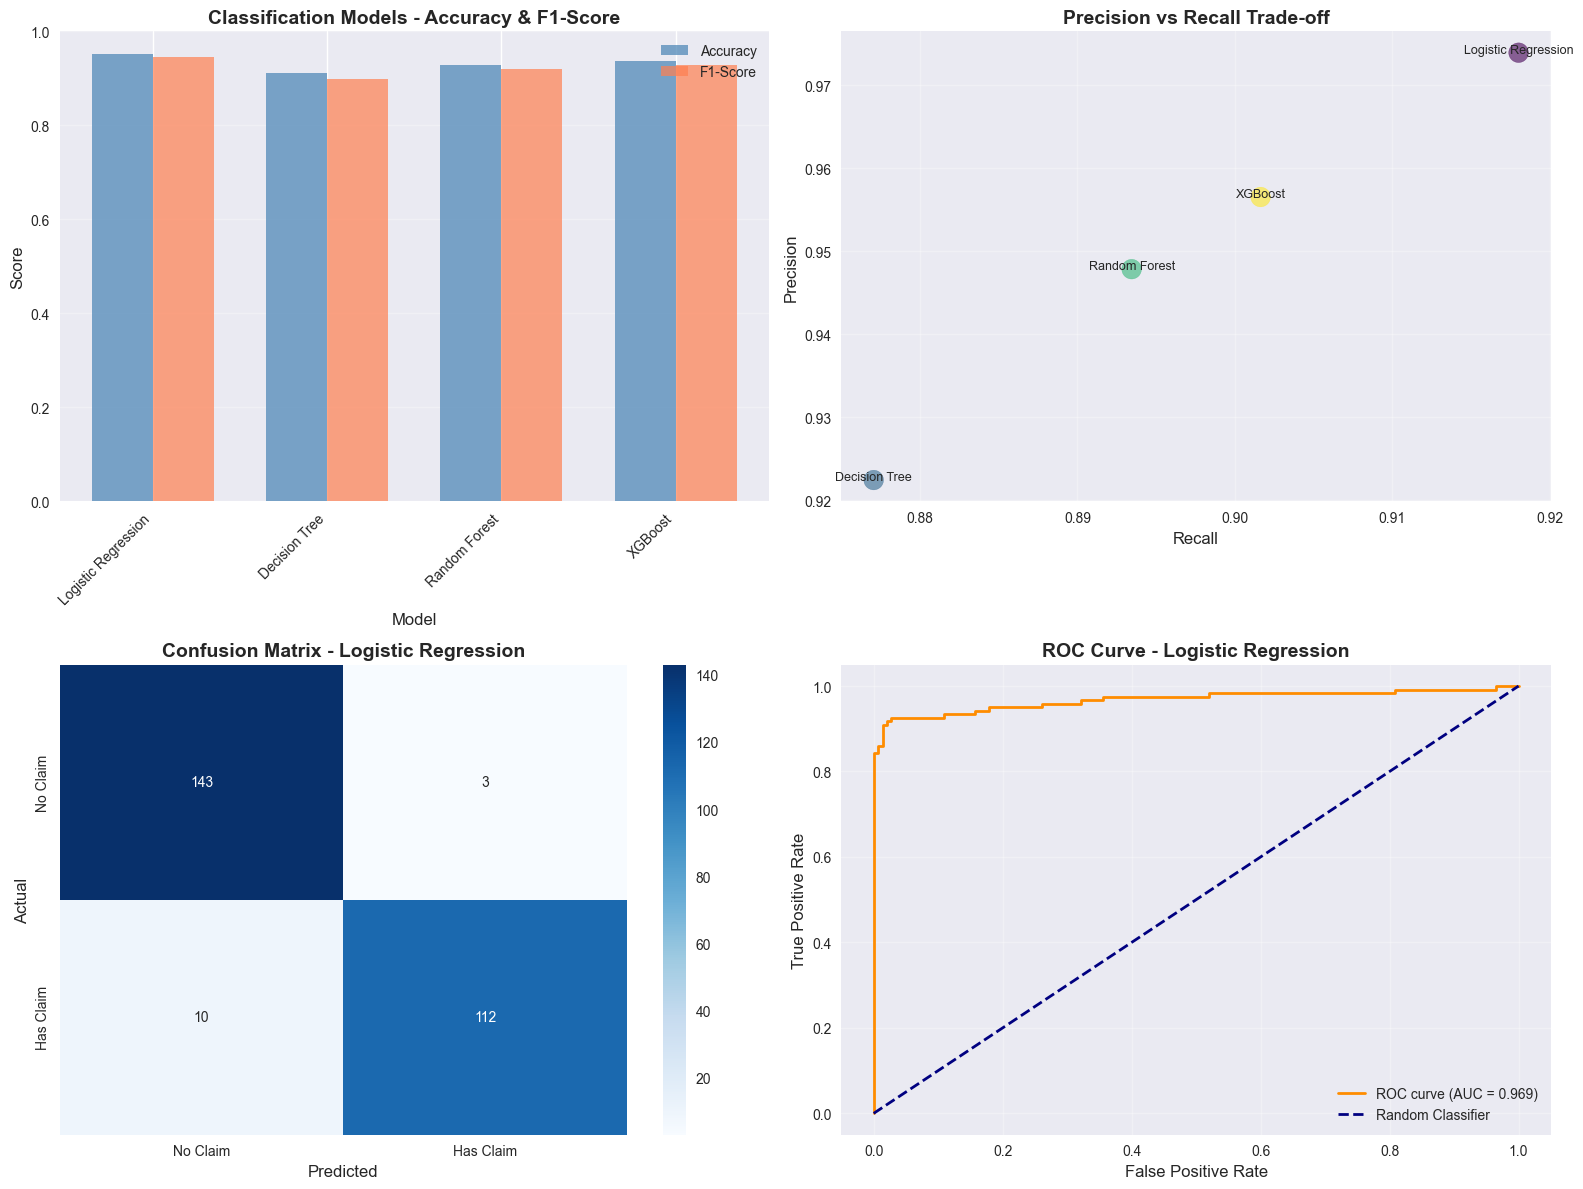

In [58]:
# Compare classification models
classification_comparison = []
for model_name, metrics in claim_prob_results.items():
    classification_comparison.append({
        'Model': model_name,
        'Test Accuracy': metrics['test_accuracy'],
        'Test Precision': metrics['test_precision'],
        'Test Recall': metrics['test_recall'],
        'Test F1-Score': metrics['test_f1'],
        'Train Accuracy': metrics['train_accuracy']
    })

classification_df = pd.DataFrame(classification_comparison)
print("="*70)
print("CLAIM PROBABILITY PREDICTION MODEL COMPARISON")
print("="*70)
print(classification_df.to_string(index=False))
print("="*70)

# Identify best classification model
best_clf_model_name = classification_df.loc[classification_df['Test F1-Score'].idxmax(), 'Model']
best_clf_model = claim_prob_models[best_clf_model_name]
print(f"\n✓ Best Classification Model: {best_clf_model_name}")
print(f"  Test Accuracy: {classification_df.loc[classification_df['Test F1-Score'].idxmax(), 'Test Accuracy']:.4f}")
print(f"  Test F1-Score: {classification_df.loc[classification_df['Test F1-Score'].idxmax(), 'Test F1-Score']:.4f}")

# ============================================================================
# CLASSIFICATION MODEL PERFORMANCE VISUALIZATIONS
# ============================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model comparison - Accuracy and F1-Score
x = np.arange(len(classification_df))
width = 0.35
axes[0, 0].bar(x - width/2, classification_df['Test Accuracy'], width, label='Accuracy', color='steelblue', alpha=0.7)
axes[0, 0].bar(x + width/2, classification_df['Test F1-Score'], width, label='F1-Score', color='coral', alpha=0.7)
axes[0, 0].set_xlabel('Model', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Classification Models - Accuracy & F1-Score', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(classification_df['Model'], rotation=45, ha='right')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Precision vs Recall
axes[0, 1].scatter(classification_df['Test Recall'], classification_df['Test Precision'], 
                   s=200, alpha=0.6, c=range(len(classification_df)), cmap='viridis')
for i, model in enumerate(classification_df['Model']):
    axes[0, 1].annotate(model, (classification_df['Test Recall'].iloc[i], 
                                classification_df['Test Precision'].iloc[i]),
                       fontsize=9, ha='center')
axes[0, 1].set_xlabel('Recall', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision vs Recall Trade-off', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix (best model)
y_test_pred_best_clf = best_clf_model.predict(X_test_claim_prob)
cm = confusion_matrix(y_test_claim_prob, y_test_pred_best_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
            xticklabels=['No Claim', 'Has Claim'], yticklabels=['No Claim', 'Has Claim'])
axes[1, 0].set_xlabel('Predicted', fontsize=12)
axes[1, 0].set_ylabel('Actual', fontsize=12)
axes[1, 0].set_title(f'Confusion Matrix - {best_clf_model_name}', fontsize=14, fontweight='bold')

# 4. ROC Curve (best model)
y_test_proba_best = best_clf_model.predict_proba(X_test_claim_prob)[:, 1]
fpr, tpr, _ = roc_curve(y_test_claim_prob, y_test_proba_best)
roc_auc = auc(fpr, tpr)
axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 1].set_title(f'ROC Curve - {best_clf_model_name}', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = figures_dir / 'ml_classification_performance.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()


## 10. Risk-Based Premium Calculation

**Formula**: Premium = (Predicted Probability of Claim × Predicted Claim Severity) + Expense Loading + Profit Margin

This combines:
1. **Claim Probability Model**: Predicts likelihood of a claim (from Section 9)
2. **Claim Severity Model**: Predicts claim amount if claim occurs (from Section 3)
3. **Business Parameters**: Expense loading and profit margin


RISK-BASED PREMIUM CALCULATION
Formula: Premium = (P(Claim) × Expected Claim Severity) + Expenses + Profit

Business Parameters:
  - Expense Loading: 15.0%
  - Profit Margin: 10.0%

RISK-BASED PREMIUM PERFORMANCE
Test RMSE: $6,420.62
Test R²: 0.7345
Test MAE: $4,627.47

Comparison with Direct Prediction Model:
  Direct Model RMSE: $4,459.76
  Risk-Based RMSE: $6,420.62
  Difference: $1,960.86

SAMPLE RISK-BASED PREMIUM CALCULATIONS (First 10 records)
Actual Charges Direct Prediction Risk-Based Premium P(Claim) Expected Severity
     $9,095.07        $11,329.21          $9,900.76   34.08%        $21,786.55
     $5,272.18         $5,978.75          $1,145.39    4.20%        $20,451.84
    $29,330.98        $28,457.86         $38,680.82  100.00%        $29,010.63
     $9,301.89        $10,060.28          $9,329.61   35.57%        $19,672.42
    $33,750.29        $35,183.02         $44,002.03   96.41%        $34,230.86
     $4,536.26         $6,540.98            $714.49    3.57%        $14

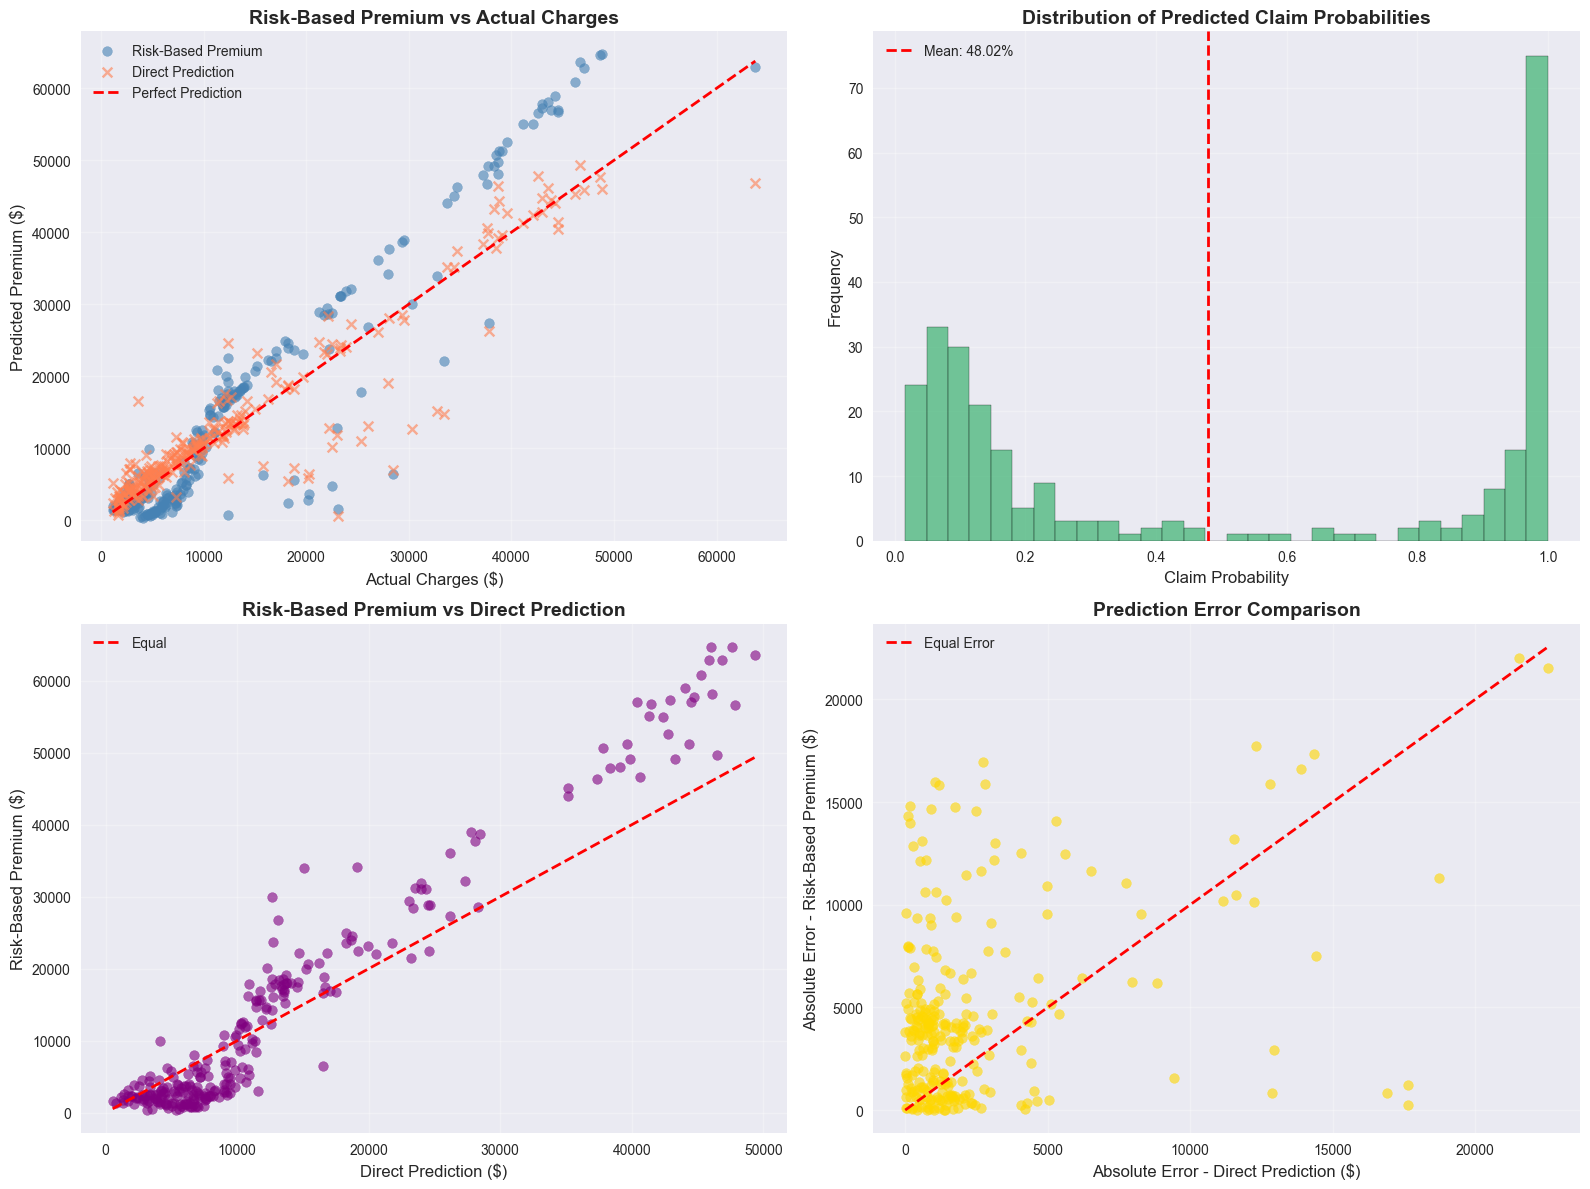

In [59]:
# ============================================================================
# RISK-BASED PREMIUM CALCULATION
# ============================================================================
# Formula: Premium = (Predicted Probability × Predicted Severity) + Expenses + Profit
# ============================================================================

# Business parameters (example values - adjust based on business requirements)
EXPENSE_LOADING = 0.15  # 15% of base premium for operational expenses
PROFIT_MARGIN = 0.10    # 10% profit margin

print("="*70)
print("RISK-BASED PREMIUM CALCULATION")
print("="*70)
print(f"Formula: Premium = (P(Claim) × Expected Claim Severity) + Expenses + Profit")
print(f"\nBusiness Parameters:")
print(f"  - Expense Loading: {EXPENSE_LOADING:.1%}")
print(f"  - Profit Margin: {PROFIT_MARGIN:.1%}")

# Use best models
# 1. Claim probability (from classification model)
# 2. Claim severity (from regression model on claims subset)

# Calculate risk-based premiums for test set
# Step 1: Predict claim probability
claim_probabilities = best_clf_model.predict_proba(X_test_premium)[:, 1]

# Step 2: Predict claim severity (for all records, but we'll use it conditionally)
# Note: The severity model was trained only on claims, so we predict for all
# In practice, we'd only use severity if probability > threshold
severity_predictions = best_model_claims.predict(X_test_premium)

# Step 3: Calculate risk-based premium
# Premium = (P(Claim) × Expected Severity) × (1 + Expense Loading) × (1 + Profit Margin)
# Or more simply: Premium = (P(Claim) × Expected Severity) / (1 - Expense Loading - Profit Margin)
risk_based_premiums = (claim_probabilities * severity_predictions) / (1 - EXPENSE_LOADING - PROFIT_MARGIN)

# Compare with actual charges and simple model predictions
comparison_premiums = pd.DataFrame({
    'Actual Charges': y_test_premium.values,
    'Direct Prediction': best_model_premium.predict(X_test_premium),
    'Risk-Based Premium': risk_based_premiums,
    'Claim Probability': claim_probabilities,
    'Expected Severity': severity_predictions
})

# Calculate metrics for risk-based premium
risk_premium_rmse = np.sqrt(mean_squared_error(y_test_premium, risk_based_premiums))
risk_premium_r2 = r2_score(y_test_premium, risk_based_premiums)
risk_premium_mae = mean_absolute_error(y_test_premium, risk_based_premiums)

print(f"\n" + "="*70)
print("RISK-BASED PREMIUM PERFORMANCE")
print("="*70)
print(f"Test RMSE: ${risk_premium_rmse:,.2f}")
print(f"Test R²: {risk_premium_r2:.4f}")
print(f"Test MAE: ${risk_premium_mae:,.2f}")

print(f"\nComparison with Direct Prediction Model:")
print(f"  Direct Model RMSE: ${comparison_premium.iloc[0]['Test RMSE']:,.2f}")
print(f"  Risk-Based RMSE: ${risk_premium_rmse:,.2f}")
print(f"  Difference: ${abs(comparison_premium.iloc[0]['Test RMSE'] - risk_premium_rmse):,.2f}")

# Display sample predictions
print(f"\n" + "="*70)
print("SAMPLE RISK-BASED PREMIUM CALCULATIONS (First 10 records)")
print("="*70)
sample_comparison = comparison_premiums.head(10).copy()
sample_comparison['P(Claim)'] = sample_comparison['Claim Probability']
sample_comparison['Expected Severity'] = sample_comparison['Expected Severity']
sample_comparison = sample_comparison[['Actual Charges', 'Direct Prediction', 'Risk-Based Premium', 'P(Claim)', 'Expected Severity']]
for col in ['Actual Charges', 'Direct Prediction', 'Risk-Based Premium', 'Expected Severity']:
    sample_comparison[col] = sample_comparison[col].apply(lambda x: f"${x:,.2f}")
sample_comparison['P(Claim)'] = sample_comparison['P(Claim)'].apply(lambda x: f"{x:.2%}")
print(sample_comparison.to_string(index=False))
print("="*70)

# ============================================================================
# RISK-BASED PREMIUM VISUALIZATIONS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Risk-Based Premium vs Actual Charges
axes[0, 0].scatter(comparison_premiums['Actual Charges'], comparison_premiums['Risk-Based Premium'], 
                   alpha=0.6, color='steelblue', label='Risk-Based Premium')
axes[0, 0].scatter(comparison_premiums['Actual Charges'], comparison_premiums['Direct Prediction'], 
                   alpha=0.6, color='coral', label='Direct Prediction', marker='x')
axes[0, 0].plot([comparison_premiums['Actual Charges'].min(), comparison_premiums['Actual Charges'].max()], 
                [comparison_premiums['Actual Charges'].min(), comparison_premiums['Actual Charges'].max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Charges ($)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Premium ($)', fontsize=12)
axes[0, 0].set_title('Risk-Based Premium vs Actual Charges', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Claim Probability Distribution
axes[0, 1].hist(comparison_premiums['Claim Probability'], bins=30, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0, 1].axvline(comparison_premiums['Claim Probability'].mean(), color='red', linestyle='--', 
                  linewidth=2, label=f'Mean: {comparison_premiums["Claim Probability"].mean():.2%}')
axes[0, 1].set_xlabel('Claim Probability', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Predicted Claim Probabilities', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Premium Comparison (Risk-Based vs Direct)
axes[1, 0].scatter(comparison_premiums['Direct Prediction'], comparison_premiums['Risk-Based Premium'], 
                   alpha=0.6, color='purple')
axes[1, 0].plot([comparison_premiums['Direct Prediction'].min(), comparison_premiums['Direct Prediction'].max()], 
                [comparison_premiums['Direct Prediction'].min(), comparison_premiums['Direct Prediction'].max()], 
                'r--', linewidth=2, label='Equal')
axes[1, 0].set_xlabel('Direct Prediction ($)', fontsize=12)
axes[1, 0].set_ylabel('Risk-Based Premium ($)', fontsize=12)
axes[1, 0].set_title('Risk-Based Premium vs Direct Prediction', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Error Comparison
error_direct = np.abs(comparison_premiums['Actual Charges'] - comparison_premiums['Direct Prediction'])
error_risk = np.abs(comparison_premiums['Actual Charges'] - comparison_premiums['Risk-Based Premium'])
axes[1, 1].scatter(error_direct, error_risk, alpha=0.6, color='gold')
axes[1, 1].plot([error_direct.min(), error_direct.max()], 
                [error_direct.min(), error_direct.max()], 
                'r--', linewidth=2, label='Equal Error')
axes[1, 1].set_xlabel('Absolute Error - Direct Prediction ($)', fontsize=12)
axes[1, 1].set_ylabel('Absolute Error - Risk-Based Premium ($)', fontsize=12)
axes[1, 1].set_title('Prediction Error Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = figures_dir / 'ml_risk_based_premium.png'
plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
print(f"✓ Saved figure: {fig_path}")
plt.show()
